<a href="https://colab.research.google.com/github/BenaribIlyes/Edge_computing/blob/main/code/edge_computing_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Edge Computing Project: Embedded Speech Recognition

## Project Overview

This project aims to explore the role of a **Data Scientist** in a **constrained environment** (embedded systems). The goal is to provide a comprehensive view of the entire pipeline—from model creation to deployment on resource-limited devices.

### Key Objectives
- **Speech Recognition**: Focus on a real-world Natural Language Processing (NLP) task, where embedded AI is in high demand (e.g., smart speakers, smartphones, wearables).
- **Model Optimization**: Develop and optimize a 1D convolutional or recurrent model to classify 12 labels from the [TensorFlow Speech Recognition Challenge dataset](https://www.kaggle.com/c/tensorflow-speech-recognition-challenge) (hosted on Kaggle).
- **Performance Analysis**: Visualize and analyze model performance as it is progressively lightweighted for embedded deployment.
- **Critical Thinking**: Emphasize problem analysis, solution design, and performance evaluation.

---

## Project Structure

This project is organized into **five 4-hour practical sessions**, each focusing on a specific phase of the development process:

1. **Dataset Analysis**: Understand the structure, features, and challenges of the dataset.
2. **State of the Art**: Review existing solutions and benchmark approaches.
3. **Preprocessing**: Prepare the data for model training (e.g., feature extraction, normalization).
4. **Model Training**: Design, train, and optimize a 1D convolutional or recurrent model.
5. **Results and Discussion**: Evaluate model performance and discuss insights.
6. **Model Lightweighting**: Optimize the model for embedded deployment.
7. **Conclusion**: Summarize findings, challenges, and future directions.

---

## Methodology

### Leveraging Existing Solutions
As a Data Scientist, it is essential to **build on existing work**. The AI community is vast, and most challenges have been addressed before. Platforms like Kaggle provide datasets and competitions (e.g., the TensorFlow Speech Recognition Challenge, organized by Google with prizes up to $25,000) to foster innovation and collaboration.

### Dataset
The project uses the **TensorFlow Speech Recognition Challenge dataset** from Kaggle, which contains audio samples labeled with 12 distinct classes. The goal is to classify these labels accurately using a custom model.

### Model Development
- **Architecture**: 1D convolutional or recurrent neural networks.
- **Optimization**: Focus on accuracy, inference speed, and model size for embedded deployment.
- **Evaluation**: Performance metrics (e.g., accuracy, F1-score) and visualization of trade-offs between model complexity and performance.

---

## Collaboration and Ethics

- **Collaboration**: Teamwork and peer support are encouraged to foster learning and creativity.
- **Academic Integrity**: Plagiarism is strictly prohibited. All work must be original, and sources must be cited appropriately.
- **Critical Analysis**: Document your reasoning, choices, and reflections throughout the project.

---

## Expected Outcomes

By the end of this project, you will:
- Gain hands-on experience in **embedded AI** and **speech recognition**.
- Develop skills in **data analysis, model optimization, and performance evaluation**.
- Understand the challenges and trade-offs in deploying AI models on constrained devices.

---


# Analyse de la base de données 

La première étape est de télecharger et d'analyser la base de donnée. Pour cela rendez vous sur le site de la compétition:
https://www.kaggle.com/competitions/tensorflow-speech-recognition-challenge/overview

Pensez à bien regarder la compétition en détail, cela pourra vous être très utile (comme par exemple trouver du code ou des articles).

# Information sur la base de donnée

Tips: Parlez de tous ce que vous savez des données (quantité d'instances, les labels, la taille d'une time series, sa fréquence d'echantillonage, ...).

Le dossier contient trois fichiers principaux :
- Train.7z : Les données d'entraînement sont des enregistrements d'une seconde. La fréquence d'échantillonnage est de 16 KHz . Les labels à prédire sont : yes, no, up, down, left, right, on, off, stop, go.

-Test.7z : Contient un dossier de 150,000+ fichiers au format wav.

-Sample_submission.csv - Un exemple de rendu.
Visualitation d'une donnée et analyse critique

Tips: Faites un subplot de plusieurs labels différents pour voir visuellement les différences. 

# Visualitation d'une donnée et analyse critique

Tips: Faites un subplot de plusieurs labels différents pour voir visuellement les différences.

    Ecrire votre texte ici.



In [1]:
SEED = 42

import os
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
from scipy.io import wavfile
import tensorflow as tf
import sys

# Ajoute les chemins des librairies Conda au système pour que TF les trouve
conda_prefix = os.environ.get('CONDA_PREFIX')
if conda_prefix:
    # Chemins types sous Linux/WSL
    os.environ['LD_LIBRARY_PATH'] = f"{conda_prefix}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
    

# On garde le memory growth par sécurité
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("Configuration forcée des chemins CUDA terminée.")

2025-12-09 09:11:28.965369: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 09:11:29.408982: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-09 09:11:29.409103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-09 09:11:29.460781: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-09 09:11:29.592773: I tensorflow/core/platform/cpu_feature_guar

Configuration forcée des chemins CUDA terminée.


2025-12-09 09:11:33.919469: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-09 09:11:34.440708: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-09 09:11:34.443720: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

# Pour utilisation sur  Google collab


In [2]:
#from google.colab import drive # Pour google colab
#drive.mount('/content/drive')  # Pour google colab

# Ajouter ce dossier dans votre drive: https://drive.google.com/drive/folders/1AAiaDTWJzvS6NaZXE_dfJ603QWhhcl0R?usp=sharing
# train_data_path = '/home/zebre/Bureau/IATI/3A/IA_et_materiel/edge_computing/Edge_computing/data/tensorflow-speech-recognition-challenge/train/audio'

# Pour utilisation sur un IDE local

In [3]:
#Préciser le path des données d'entrainements ici
train_data_path = '/home/zebre/Bureau/eddge_computing/Edge_computing/data/train/audio'

#Préciser le path des données de test ici
test_data_path = '/home/zebre/Bureau/eddge_computing/Edge_computing/data/test/audio'


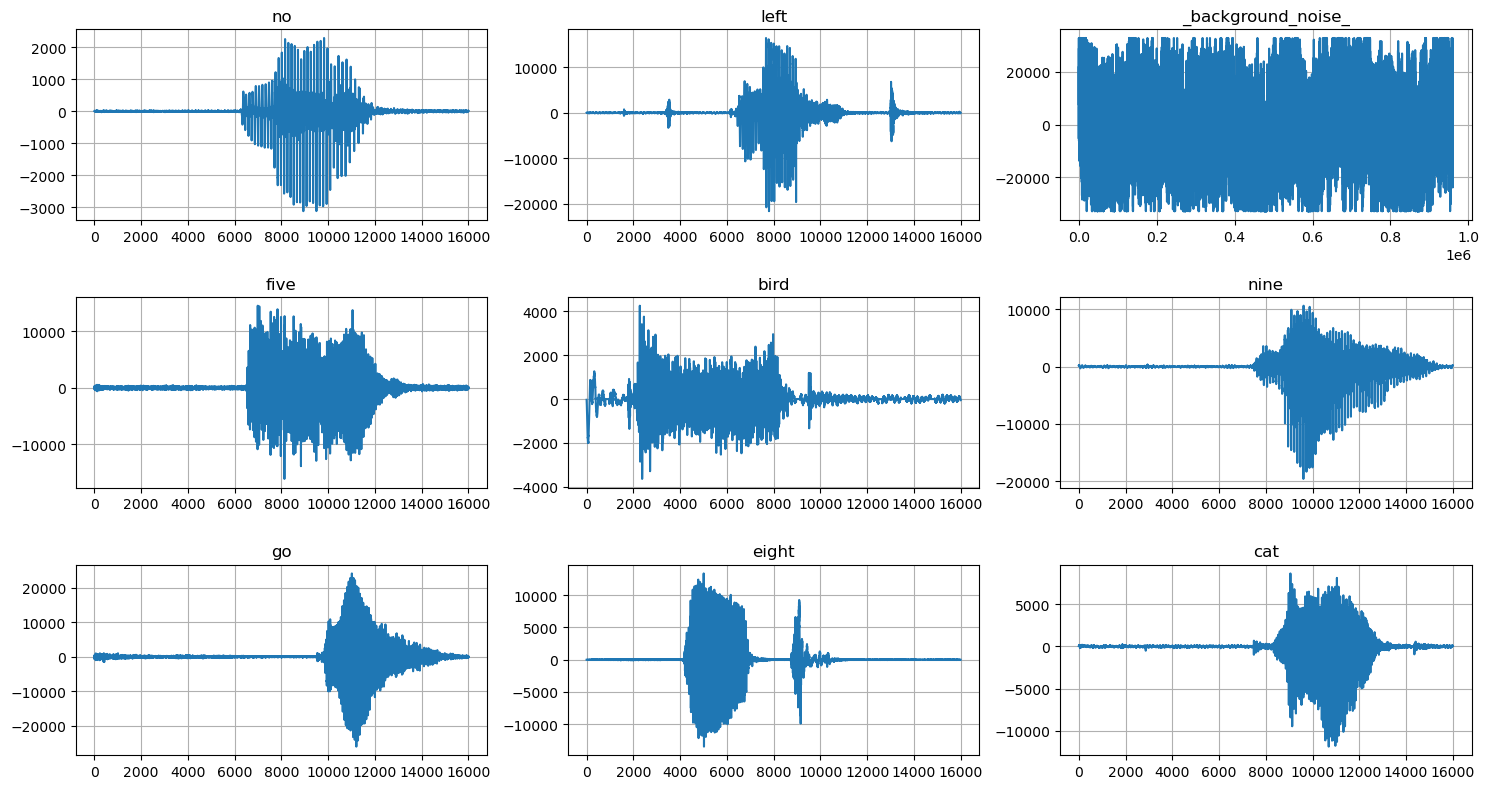

In [4]:
# Chemin vers les données

labels = os.listdir(train_data_path)[1:]  # On ignore le premier fichier


# Sélection aléatoire de 9 labels
np.random.seed(seed = SEED)
Random_Labels = np.random.choice(labels, size=9, replace=False)

plt.figure(figsize=(15, 8))

for i, label in enumerate(Random_Labels, 1):
    wav_files_path = os.path.join(train_data_path, label)
    random_wav = np.random.choice(os.listdir(wav_files_path))  # un fichier wav aléatoire
    sr, time_series = wavfile.read(os.path.join(wav_files_path, random_wav))

    plt.subplot(3, 3, i)
    plt.plot(time_series)
    plt.grid()
    plt.title(label)

plt.tight_layout()
plt.show()


### Stockage des données
 <font color="red"> **ATTENTION:** Respectez l'ordre des labels: 0 = yes, 1 = no, 2 = up, 3 = down, 4 = left, 5 = right, 6 = on, 7 = off, 8 = stop, 9 = go, 10 = silence, 11 = unknown </font>

<font color=" Darkblue"> **Tips:** Réduisez la taille des données d'entrées afin d'éviter la saturation de la mémoire </font>

In [5]:
import pandas as pd  

# Dictionnaire pour identifier les label
Data_Dict = {
      "yes": 0,
      "no": 1,
      "up": 2,
      "down": 3,
      "left": 4,
      "right": 5,
      "on": 6,
      "off": 7,
      "stop": 8,
      "go": 9,
      "_background_noise_": 10,
      "unknown": 11
}

# Dictionnaire inversé pour l'affichage 
ID_to_Label = {v: k for k, v in Data_Dict.items()}

# Constante utilisée dans le code pour représenter l'ID "unknown"
# On récupère la valeur depuis Data_Dict pour éviter NameError si la clé change.
UNKNOWN_ID = Data_Dict.get("unknown", Data_Dict.get("UNKNOWN_ID", 11))


def import_data_as_dataframe(max_files_per_label=100, max_unknown=100, data_path=train_data_path, seed=42, shuffle=True):
    ''' Création d'un dataframe avec les données nécéssaires '''
    rows = []

    # 1) Scanner tous les fichiers et construire la méta-table
    for label in os.listdir(data_path):
        label_path = os.path.join(data_path, label)
        if not os.path.isdir(label_path):
            continue

        label_id = Data_Dict.get(label, UNKNOWN_ID)
        label_name = ID_to_Label.get(label_id, "unknown")

        wav_files = [f for f in os.listdir(label_path) if f.endswith(".wav")]

        for wav_file in wav_files:
            file_path = os.path.join(label_path, wav_file)
            rows.append(
                {
                    "file_path": file_path,
                    "label_id": label_id,
                    "label_name": label_name,
                }
            )

    df_all = pd.DataFrame(rows)

    # 2) Sampling par label (avec quota spécial pour UNKNOWN)
    sampled_dfs = []
    rng = np.random.RandomState(seed)

    for label_id, group in df_all.groupby("label_id"):
        if label_id == UNKNOWN_ID:
            n = min(len(group), max_unknown)
        else:
            n = min(len(group), max_files_per_label)

        sampled = group.sample(n=n, random_state=rng)
        sampled_dfs.append(sampled)

    df = pd.concat(sampled_dfs, ignore_index=True)

    # 3) Shuffle global optionnel
    if shuffle:
        df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # 4) Lecture des waves suivant le DF final
    all_waves = []
    for file_path in df["file_path"]:
        sr, samples = wavfile.read(file_path)

        if len(samples) > 16000:
            samples = samples[:16000]
        else:
            samples = np.pad(samples, (0, 16000 - len(samples)))

        all_waves.append(samples)

    X = np.array(all_waves) 
    # On peut ne garder que les colonnes de labels si tu veux
    df_labels = df[["label_id", "label_name"]].copy()

    return X, df_labels


In [6]:
waves, waves_labels = import_data_as_dataframe(max_files_per_label=1000, max_unknown=1000, data_path=train_data_path, seed=42, shuffle=True)
print("Formats des données = ",waves.shape)
print("Formats des labels = ",waves_labels.shape)

/tmp/ipykernel_6165/423456611.py:76: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(file_path)


Formats des données =  (11006, 16000)
Formats des labels =  (11006, 2)


On obtient 11 006 enregsitrement en considérant 1000 fichiers wav par classe (avec 12 classes) car on ne dispose que de 6 enregsitemnt de silence.

In [7]:
# Exemple de donnée
id_exemple = 3

# Signal audio
signal_ex = waves[id_exemple]

# ID + nom du label via le DataFrame
label_id_ex = waves_labels.loc[id_exemple, "label_id"]
label_name_ex = waves_labels.loc[id_exemple, "label_name"]

print(f"Exemple d'échantillon de données : {signal_ex}")
print(f"ID du label : {label_id_ex}")
print(f"Nom du label : {label_name_ex}")

# Lecture audio
ipd.Audio(signal_ex, rate=16000)


Exemple d'échantillon de données : [3 2 1 ... 0 0 0]
ID du label : 4
Nom du label : left


## Etat de l'art

Etape importante qui suit: faire un état de l'art. Que cela soit pour innover, ou pour trouver une solution existante pertinente, faire un état de l'art scientifique est essentiel. Ici, vous devez chercher les articles liés à ce projet. Il faut pour cela remplir le tableau et bien marquer leurs références en dessous. De plus, un texte synthétique vous sera demandé pour expliquer selon vous, quels papiers sont les plus pertinants pour la suite de ce projet.

Attention: une analyse critique est nécessaire sur ces papiers (certain papiers peuvent avoir des biais cachés).

<font color="orange"> **Note anti-plagiat:** Au moins 2 références devraient être différente des autres binômes. </font>

&nbsp;


<font color="Darkred"> Progression du TP après cette partie (environ 2h):

&nbsp;

---

Le véritable état de l'art pour ce défi est construit autour de deux axes majeurs : la définition du jeu de données et la conception d'architectures optimisées pour les contraintes d'embarqué.

### Tableau Récapitulatif

| Article | Références | Preprocessing | Modèle | Solution Embarquée ? | Dataset utilisé | Performances (Baseline) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Warden (2018) [1]** | [1] Speech Commands [cite: 1, 10] | Normalisation à 1 seconde, 16 KHz[cite: 1, 5]. Extraction de la section la plus forte pour l'alignement[cite: 1]. | CNN (Convolutional Neural Network) [cite: 1] – Inspiré de Sainath & Parada[cite: 1]. | **Oui, objectif principal.** Modèles petits, faible consommation d'énergie, minimisation des faux positifs[cite: 1]. | **Speech Commands Dataset v2** (105 829 énonciations de 35 mots)[cite: 1]. | **Top-One Accuracy : 88.2%** (Baseline CNN sur V2)[cite: 1]. |
| **Zhang et al. (2017) [2]** | [2] Hello Edge [cite: 2] | Conversion du signal audio en **représentations 2D** (Spectrogrammes ou Mel-Spectrogrammes)[cite: 2]. | **DS-CNN** (Depthwise Separable CNN) – Architecture la plus efficace pour les contraintes de taille et de performance[cite: 2]. | **Oui.** Comparaison de l'efficacité des architectures pour l'exécution sur microcontrôleurs (CMSIS-NN)[cite: 2, 8]. | Similaire à [1] (Speech Commands V1)[cite: 2]. | Meilleur équilibre entre précision et efficacité énergétique/taille du modèle[cite: 2]. |

---


## Références

Les références complètes (format IEEE) pour les sources utilisées dans cette analyse :

1.  P. Warden, "Speech Commands: A Dataset for Limited-Vocabulary Speech Recognition," *arXiv e-prints*, 2018, art. no. arXiv:1804.03209.
2.  Y. Zhang, N. Suda, L. Lai et V. Chandra, "Hello Edge: Keyword Spotting on Microcontrollers," *arXiv e-prints*, 2017, art. no. arXiv:1711.07128.
3.  (2018) Speech commands dataset version 2. [Online]. Available: http://download.tensorflow.org/data/speech_commands\_v0.02.tar.gz [cite: 1]
4.  (2017) Speech commands dataset version 1. [Online]. Available: http://download.tensorflow.org/data/speech\_commands\_v0.01.tar.gz [cite: 1]
5.  (2018) Linguistic data consortium. [Online]. Available: https://www.ldc.upenn.edu/ [cite: 1]
6.  J. Deng, W. Dong, R. Socher, L.-J. Li, K. Li, and L. Fei-Fei, "ImageNet: A Large-Scale Hierarchical Image Database," in CVPR09, 2009. [cite: 1]
7.  T. N. Sainath and C. Parada, "Convolutional Neural Networks for Small-Footprint Keyword Spotting," in Sixteenth Annual Conference of the International Speech Communication Association, 2015. [Online]. Available: https://www.isca-speech.org/archive/interspeech\_2015/papers/i15\_1478.pdf [cite: 1]
8.  L. Lai, N. Suda, and V. Chandra, "CMSIS-NN: Efficient Neural Network Kernels for Arm Cortex-M CPUs," ArXiv e-prints, Jan. 2018. [cite: 1]
9.  R. Tang and J. Lin, "Deep Residual Learning for Small-Footprint Keyword Spotting," ArXiv e-prints, Oct. 2017. [cite: 1]
10. S. Krishna Gouda, S. Kanetkar, D. Harrison, and M. K. Warmuth, "Speech Recognition: Keyword Spotting Through Image Recognition," ArXiv e-prints, Mar. 2018. [cite: 1]

## Preprocessing

C'est la partie la plus importante du projet !! Même le modèle le plus performant de la terre ne pourra pas être précis sans des données d'entrées propres. De plus, il est important de réduire la quantité de données d'entrée (Décimation) afin de ne pas avoir un modèle trop lourd.

<font color=" Darkblue"> **Tips:** Commencez par un preprocessing simple, et améliorez le lorsque les modèles seront en cours d'apprentissage. </font>

Voici quelques sources qui pourront vous être utile pour faire votre code, en plus de l'état de l'art précedemment fait:
- https://medium.com/enjoy-algorithm/pre-processing-of-time-series-data-c50f8a3e7a98
- https://monkeylearn.com/blog/data-preprocessing/
- https://machinelearningmastery.com/machine-learning-data-transforms-for-time-series-forecasting/
- https://haythamfayek.com/2016/04/21/speech-processing-for-machine-learning.html (pour les plus expérimenté d'entre vous)

&nbsp;

<font color=" Darkred"> Progression du TP après cette partie (environ 3h): </font>  
![56%](https://progress-bar.dev/56)


### Zone d'expérimentation

Ici vous êtes libre d'essayer des choses, les visualiser, avoir un regard critique sur la solution que vous décidez de prendre. Utilisez autant de cases de codes et de textes.

**PS** : En général, l'ordre à suivre pour faire du preprocessing avec ces fonctions est : Power Transform, Seasonal Difference, Trend Difference,Standardization, Normalization.

In [8]:
# Fonctions de prétraitement audio (inspirées de la doc)

import numpy as np
from scipy.fftpack import dct

def To_normalize(signal, eps=1e-8):
    """Normalise un enregistrement audio en [-1, 1] par son max absolu."""
    signal = signal.astype(np.float32)
    max_abs = np.max(np.abs(signal)) + eps
    return signal / max_abs


def pre_emphasis_filter(signal, coefficient=0.97):
    """"Filtre numérique passe haut (dérivateur) amplififiant les hautes fréquence, fc = 100Hz (valeur classique)"""
    return signal - coefficient * np.roll(signal, 1)


def framing(signal, frame_length, frame_step, sample_rate):
    """Découpe le signal en trames de durée fixe (fenêtrage temporel)."""
    signal_length = len(signal)
    frame_length = int(round(frame_length * sample_rate))
    frame_step = int(round(frame_step * sample_rate))

    num_frames = int(np.floor((signal_length - frame_length) / frame_step)) + 1
    pad_signal_length = num_frames * frame_step + frame_length
    z = np.zeros((pad_signal_length - signal_length))
    pad_signal = np.append(signal, z)

    indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + \
              np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T

    frames = pad_signal[indices.astype(np.int32, copy=False)]
    return frames


def window_hamming(frames):
    """Applique une fenêtre de Hamming pour lisser les trames."""
    frame_length = len(frames[0])
    windowed_frames = np.zeros(frames.shape)
    for i in range(len(frames)):
        windowed_frames[i] = frames[i] * np.hamming(frame_length)
    return windowed_frames


def fft(windowed_frames, NFFT=512):
    """Calcule le spectre de puissance de chaque trame (FFT)."""
    mag_frames = np.absolute(np.fft.rfft(windowed_frames, NFFT))
    pow_frames = ((1.0 / NFFT) * (mag_frames ** 2))
    return pow_frames


def filter_bank(pow_frames, sample_rate, NFFT=512, nfilt=40):
    """Applique un banc de filtres de Mel pour regrouper les fréquences."""
    low_freq_mel = 0
    high_freq_mel = 2595 * np.log10(1 + (sample_rate / 2) / 700)
    mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2)
    hz_points = 700 * (10**(mel_points / 2595) - 1)
    bin = np.floor((NFFT + 1) * hz_points / sample_rate)

    fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
    for m in range(1, nfilt + 1):
        f_m_minus = int(bin[m - 1])
        f_m = int(bin[m])
        f_m_plus = int(bin[m + 1])

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])

    filter_banks = np.dot(pow_frames, fbank.T)
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    filter_banks = 20 * np.log10(filter_banks)
    return filter_banks


def mfcc_coeffs(filter_banks, num_ceps=12, ceplifter=22):
    """Extrait les coefficients cepstraux MFCC à partir des filtres de Mel."""
    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1:(num_ceps + 1)]
    (nframes, ncoeff) = mfcc.shape
    n = np.arange(ncoeff)
    lift = 1 + (ceplifter / 2) * np.sin(np.pi * n / ceplifter)
    mfcc *= lift
    return mfcc


def Mean_Norm(Data):
    """Centre les données (MFCC ou filter banks) autour de leur moyenne."""
    Mean_Data = np.zeros(Data.shape)
    for i in range(Data.shape[0]):
        Mean_Data[i] = Data[i] - np.mean(Data[i])
    return Mean_Data


Taille du signal :(16000,)
Taille du signal filtré :(16000,)
Taille des fenêtres :(98, 400)
Taille des fenêtres après hamming :(98, 400)
Taille des fenêtres après fft :(98, 257)
Taille du spectrogramme :(257, 98)
Taille des filter banks :(98, 40)
Taille des MFCCs :(98, 12)


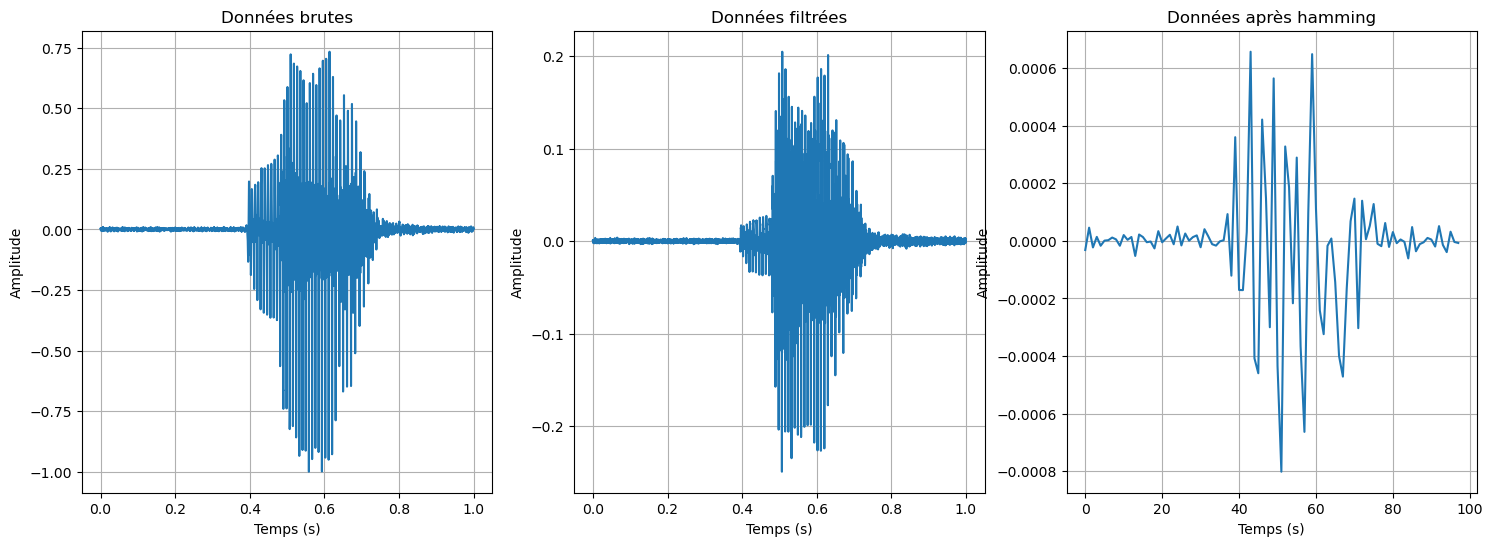

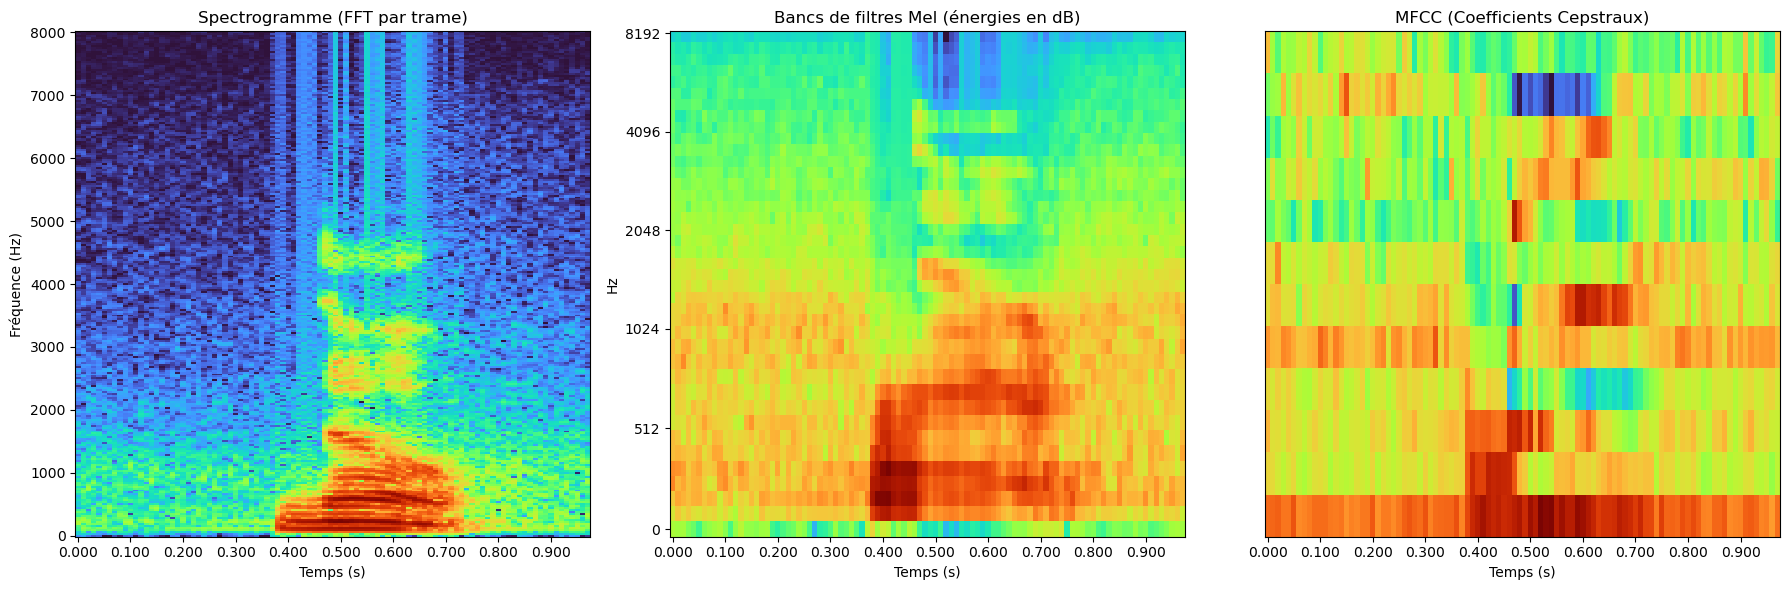

In [9]:
import librosa
import librosa.display

# Visualisation de l'effet des fonctions précédentes

# Chemin vers les données
labels = os.listdir(train_data_path)[1:]  # On ignore le premier fichier

# Sélection aléatoire d'un fichier wav
np.random.seed(SEED)
Random_Label = np.random.choice(labels, size=len(labels), replace=False)
wav_files_path = os.path.join(train_data_path, Random_Labels[0])
random_wav = np.random.choice(os.listdir(wav_files_path))  # un fichier wav aléatoire
sr, signal = wavfile.read(os.path.join(wav_files_path, random_wav))

# Application des transformations
signal = signal / np.max(np.abs(signal)) # Normalisation
emphasized_signal = pre_emphasis_filter(signal)
frames = framing(signal, frame_length=0.025, frame_step=0.01, sample_rate=sr) # fenêtres de 25ms
windowed_frames = window_hamming(frames)
pow_frames = fft(windowed_frames)
log_spectrogram = 10 * np.log10(pow_frames.T + 1e-8) # Pour la visualisation
filter_banks = filter_bank(pow_frames, sample_rate = sr)
filter_banks = Mean_Norm(filter_banks)
mfcc = mfcc_coeffs(filter_banks, num_ceps=12, ceplifter=22)
mfcc = Mean_Norm(mfcc)


# Débogage
print(f'Taille du signal :{signal.shape}')
print(f'Taille du signal filtré :{emphasized_signal.shape}')
print(f'Taille des fenêtres :{frames.shape}')
print(f'Taille des fenêtres après hamming :{windowed_frames.shape}')
print(f'Taille des fenêtres après fft :{pow_frames.shape}')
print(f'Taille du spectrogramme :{log_spectrogram.shape}')
print(f'Taille des filter banks :{filter_banks.shape}')
print(f'Taille des MFCCs :{mfcc.shape}')

### Affichage des figures

# Signaux Temporels
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(np.arange(len(signal))/sr,signal)
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.title('Données brutes')

plt.subplot(1, 3, 2)
plt.plot(np.arange(len(emphasized_signal))/sr,emphasized_signal)
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.title('Données filtrées')

plt.subplot(1, 3, 3)
plt.plot(np.arange(len(windowed_frames)),np.mean(windowed_frames, axis=1))
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title('Données après hamming')
plt.grid()

# Signaux Fréquentiels
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
librosa.display.specshow(log_spectrogram,
                         sr=sr,
                         hop_length=int(0.01 * sr),
                         x_axis='time',
                         y_axis='linear',
                         cmap='turbo')
plt.title('Spectrogramme (FFT par trame)')
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")

plt.subplot(1, 3, 2)
librosa.display.specshow(filter_banks.T, sr=sr, hop_length=int(0.01*sr),
                         x_axis='time', y_axis='mel', cmap='turbo')
plt.xlabel("Temps (s)")
plt.title("Bancs de filtres Mel (énergies en dB)")

plt.subplot(1,3,3)
librosa.display.specshow(mfcc.T, sr=sr, hop_length=int(0.01*sr),
                         x_axis='time', cmap='turbo')
plt.xlabel("Temps (s)")
plt.title("MFCC (Coefficients Cepstraux)")

plt.tight_layout()
plt.show()

### Fonction de preprocessing

> *Les fonctions réalisées précédemment serviront donc à construire la fonction de préprocessing utilisée ci-dessous pour le traitement des données, en vue de l’entraînement du réseau. Nous avons laissé libre, dans le code, le choix de travailler avec une représentation en spectrogramme, en banc de filtres de Mel ou en MFCC. Nous nous sommes concentrés sur un entraînement basé sur les MFCC, car nos cours de Traitement Automatique de la Parole ont montré qu’ils offrent la meilleure représentation temps-fréquence à traiter avec un réseau de type CNN, ce qui correspond à notre choix d’étude.*

Pour de l'audio, les démarches à suivre sont donc :   

**Normalisation de l'audio 
→ Pré-accentuation 
→ framing 
→ Fenêtrage 
→ FFT 
→ Banc de filtres Mel 
→ Calcul des MFCC 
→ Normalisation des coefficients.**

In [10]:
def To_normalize(signal, eps=1e-8):
    """Normalise un enregistrement audio en [-1, 1] par son max absolu."""
    signal = signal.astype(np.float32)
    max_abs = np.max(np.abs(signal)) + eps
    return signal / max_abs


def preprocessing(inputs,
                  type='mfccs',
                  sample_rate=16000,
                  frame_length=0.025,
                  frame_step=0.01,
                  NFFT=512,
                  nfilt=40,
                  num_ceps=12,
                  ceplifter=22):
    """
    inputs : array de forme (nb_fichiers, 16000)
    type   : 'mfccs' | 'spectrogramme' | 'mel'
    """
    clean_inputs = []
    eps = 1e-8

    for i in range(inputs.shape[0]):
        # 1) Normalisation par enregistrement
        x = To_normalize(inputs[i])               # (16000,)

        # 2) Pré-accentuation
        x = pre_emphasis_filter(x)                # (16000,)

        # 3) Framing + fenêtre de Hamming
        frames = framing(x,
                         frame_length=frame_length,
                         frame_step=frame_step,
                         sample_rate=sample_rate)  # (~nb_frames, frame_len)
        windowed_frames = window_hamming(frames)

        # 4) FFT -> spectre de puissance
        pow_frames = fft(windowed_frames, NFFT=NFFT)

        if type == 'mfccs':
            # Banc de filtres Mel
            filter_banks = filter_bank(pow_frames,
                                       sample_rate=sample_rate,
                                       NFFT=NFFT,
                                       nfilt=nfilt)
            filter_banks = Mean_Norm(filter_banks)

            # MFCC
            mfcc = mfcc_coeffs(filter_banks,
                               num_ceps=num_ceps,
                               ceplifter=ceplifter)
            mfcc = Mean_Norm(mfcc)

            max_abs = max(np.max(np.abs(mfcc)), eps)
            clean_inputs.append(mfcc / max_abs)

        elif type == 'spectrogramme':
            # Spectrogramme log
            log_spectrogram = 10 * np.log10(
                np.clip(pow_frames.T, a_min=eps, a_max=None)
            )
            max_abs = max(np.max(np.abs(log_spectrogram)), eps)
            clean_inputs.append(log_spectrogram / max_abs)

        elif type == 'mel':
            # Banc de filtres Mel sans DCT
            filter_banks = filter_bank(pow_frames,
                                       sample_rate=sample_rate,
                                       NFFT=NFFT,
                                       nfilt=nfilt)
            filter_banks = Mean_Norm(filter_banks)
            max_abs = max(np.max(np.abs(filter_banks)), eps)
            clean_inputs.append(filter_banks / max_abs)

        else:
            raise ValueError("type doit être 'mfccs', 'spectrogramme' ou 'mel'.")

    return np.array(clean_inputs, dtype=np.float32)


In [11]:
X_Data = preprocessing(waves)
Y_Data = waves_labels["label_id"]
print("Tailles de notre vecteur de données :", X_Data.shape)
print("Tailles de notre vecteur de labels :", Y_Data.shape)

Tailles de notre vecteur de données : (11006, 98, 12)
Tailles de notre vecteur de labels : (11006,)


## Apprentissage du Modèle
On y est, il est temps de créer un modèle. Pour cela, il vous sera imposé d'utiliser un réseau de convolution 1D [2] (https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv1D). Nous préconisons l'utilisation de Tensorflow mais vous êtes libre d'utiliser d'autres librairies comme Pytorch.

&nbsp;

<font color=" Darkred"> Progression du TP après cette partie (environ 3h): </font>  
![75%](https://progress-bar.dev/75)

### Train set, Validation set

Avant d'entraîner votre modèle, pensez à séparer vos données d'entraînements et vos données de validations. Puis, pensez à créer des batchs pour correspondre à l'entrée de votre modèle.

Plus d'infos ici:
 - https://www.tensorflow.org/datasets/splits?hl=fr
 - https://towardsdatascience.com/how-to-split-a-dataframe-into-train-and-test-set-with-python-eaa1630ca7b3
 - https://www.tensorflow.org/tutorials/customization/custom_training_walkthrough?hl=fr

 <font color=" Darkblue"> **Tips:** Pensez à bien mélanger vos données avant de les séparer. </font>

 <font color="orange"> **Note anti-plagiat:** Le mélange doit avoir une random seed fixe et différente pour chaque groupe. </font>

In [12]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Définirion de la seed et nombre classe
tf.random.set_seed(SEED)
NUM_CLASSES = 12

# 1. Division initiale : Entraînement (70%) et Temporaire (30%)
X_train, x_temp, y_train, y_temp = train_test_split(X_Data, Y_Data, test_size=0.3, random_state=42)

# 2. Division de l'ensemble Temporaire : Validation (15%) et Test (15%)
X_val, X_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]}")
print(f"Taille de l'ensemble de validation: {X_val.shape[0]}")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} \n")

# 3. Encodage des données
y_train = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=NUM_CLASSES)

# 4. Préparation des Datasets de tf
BATCH_SIZE = 64

X_train = np.expand_dims(X_train, axis=-1)
train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.batch(BATCH_SIZE, drop_remainder=True)

X_val = np.expand_dims(X_val, axis=-1)
val = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val = val.batch(BATCH_SIZE, drop_remainder=True)

# 5. Vérification des Dimensions
for example_inputs, example_labels in train.take(1):
    print(f'Inputs shape (batch, time/frames, features): {example_inputs.shape}')
    print(f'Labels shape (batch, num_classes): {example_labels.shape}')


Taille de l'ensemble d'entraînement: 7704
Taille de l'ensemble de validation: 1651
Taille de l'ensemble de test: 1651 

Inputs shape (batch, time/frames, features): (64, 98, 12, 1)
Labels shape (batch, num_classes): (64, 12)


2025-12-09 09:13:19.155087: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-09 09:13:19.161682: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-09 09:13:19.164281: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### Baseline

La baseline est importante afin de connaître le seuil où le modèle est performant. A vous de trouver la meilleure baseline et d'expliquer votre choix.

Plus d'infos ici:
https://towardsdatascience.com/calculating-a-baseline-accuracy-for-a-classification-model-a4b342ceb88f

> **La baseline de notre modèle doit être fixé de sorte a dépassé le Zero Rate, c'est à dire la fréquence de la classe la plus fréquente. On créer la fonction qui nous permets de calculer ce score.**

In [13]:
def calculate_zeroR_with_pandas(labels_series):
    """
    Calcule la précision du ZeroR à partir de nos données.
    """
    if labels_series.empty:
        return 0.0, None, None

    # 1. Compter la fréquence de chaque label (plus simple avec value_counts)
    # value_counts() trie déjà par fréquence (décroissant)
    label_counts = labels_series.value_counts()
    
    # 2. Identifier la classe majoritaire
    major_label_name = label_counts.index[0]
    major_label_count = label_counts.iloc[0]
    
    # 3. Calculer le taux de précision
    total_samples = len(labels_series)
    zeroR_accuracy = major_label_count / total_samples
    
    return zeroR_accuracy, major_label_name


Boucle pour calculer la baseline à partir datasframe pandas

In [14]:
# 1. Calculer le ZeroR
# Nous utilisons la colonne 'label_name' pour des résultats lisibles
accuracy, major_label = calculate_zeroR_with_pandas(waves_labels['label_name'])

# 2. Afficher les résultats
print(f"Classe majoritaire (ZeroR): '{major_label}'")
print(f"Précision du ZeroR (Baseline) : {accuracy:.4f} (soit {accuracy*100:.2f}%)")

Classe majoritaire (ZeroR): 'yes'
Précision du ZeroR (Baseline) : 0.0909 (soit 9.09%)


On as donc une baseline de 9,09 % à dépasser d'après le ZeroR.

### Modèle

Vous devez créer une fonction permettant de générer le modèle. Celle-ci doit pouvoir être modifiable en fonction des Hyperparamètres mis en entrée.

 <font color="red"> **ATTENTION:** Une limite de 150 000 paramètres est imposés. </font>

Justification de vos choix (Choix des paramètres modifiables, fonction d'activations, nombres de couches, regularizers, ...) :
> **Ecrire votre texte ici.**

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore

In [16]:
def total_param(model):
  """Calcule et affiche le nombre total de paramètres du modèle."""
  total_params = model.count_params()
  print(f"Nombre de poids du modèle: {total_params:,}")
  return total_params



In [17]:

def create_model(param, input_shape, num_classes):
  """
  Crée un modèle DS-CNN (Depthwise Separable CNN) pour une entrée 2D (ex: MFCCs).
  Les hyperparamètres sont contrôlés par le dictionnaire 'param'.
  """
  model = models.Sequential()

  # taille du kernel (tombe sur 3 si clé absente)
  k = param.get('kernell', 3)

  # --- Couche d'Entrée ---
  model.add(layers.Input(shape=input_shape))

  # --- Bloc Conv2D Standard (pour l'extraction initiale) ---
  model.add(layers.Conv2D(param['conv_filters'], (k, k), 
                           strides=(1, 1), 
                           padding='same', 
                           activation=param['activation']))
  model.add(layers.BatchNormalization())

  # --- Bloc DS-CNN 1 --- couche clé : SeparableConv2D
  model.add(layers.SeparableConv2D(param['ds_filters_1'], (k, k), 
                                    padding='same', 
                                    activation=param['activation']))
  model.add(layers.BatchNormalization())
  model.add(layers.MaxPooling2D((2, 2)))

  # --- Bloc DS-CNN 2 ---
  model.add(layers.SeparableConv2D(param['ds_filters_2'], (k, k), 
                                    padding='same', 
                                    activation=param['activation']))
  model.add(layers.BatchNormalization())
  model.add(layers.MaxPooling2D((2, 2)))

  # --- Tête de Classification ---
  model.add(layers.GlobalAveragePooling2D())
  
  model.add(layers.Dense(param['dense_units'], activation=param['activation']))
  model.add(layers.Dropout(param['dropout_rate']))
  
  # Couche de sortie finale
  model.add(layers.Dense(num_classes, activation='softmax'))
  
  return model
 
# PARAMÈTRES MIS À JOUR (pour le DS-CNN)
param = {
    'activation'    : 'relu',
    'conv_filters'  : 32,    # Filtres pour la première couche Conv2D
    'ds_filters_1'  : 64,    # Filtres pour le premier bloc DS-CNN
    'ds_filters_2'  : 64,    # Filtres pour le second bloc DS-CNN
    'dense_units'   : 32,    # Neurones dans la couche dense finale
    'dropout_rate'  : 0.5,   # Taux de dropout pour la régularisation
    'kernell'       : 3      # Taille des kernels pour la convolution 
}

# Remarque : vos entrées MFCC pré-traitées ont la forme (98, 12, 1) dans les batches.
# Adapter INPUT_SHAPE pour correspondre aux données (frames, coeffs, channels).
INPUT_SHAPE = (98, 12, 1)  # 98 timesteps, 12 coefficients MFCC, 1 canal
NUM_CLASSES= 12

model = create_model(param, INPUT_SHAPE, NUM_CLASSES)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 12, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 98, 12, 32)        128       
 Normalization)                                                  
                                                                 
 separable_conv2d (Separabl  (None, 98, 12, 64)        2400      
 eConv2D)                                                        
                                                                 
 batch_normalization_1 (Bat  (None, 98, 12, 64)        256       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 49, 6, 64)         0         
 D)                                                     

### Fonction d'entraînement

Cette fonction doit prendre un modèle en entrée et l'entrainer grâce au Train set. Puis, retourner les performances obtenues avec le Validation set.

Pour les plus expérimentés d'entre vous: Vous pouvez réaliser une cross validation [[2]](https://datascientest.com/cross-validation).

Justification de vos choix (Choix des paramètres modifiables, optimizer, nombres d'epoch, learning rate, ...) :
> **Ecrire votre texte ici.**

In [18]:
def compile_and_fit(model, train, val, param, verbose=1):
    
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20, # 20 est bien
                                                    mode='min',
                                                    restore_best_weights=True) # Important !

    # Pour les plus confirmés
    lr = tf.optimizers.schedules.ExponentialDecay(
         initial_learning_rate=1e-2,
         decay_steps=1000,
         decay_rate=0.95)

    # lr =  1e-3 # Augmentation du LR

    model.compile(loss='categorical_crossentropy', 
                metrics=['accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')])

    # 1. Capturer l'historique de l'entraînement
    history = model.fit(train, epochs=train_param['max_epochs'],
                      validation_data=val,
                      callbacks=[early_stopping], 
                      verbose=verbose)

    # 2. Évaluer le modèle (qui a restauré les meilleurs poids)
    validation_evaluation = model.evaluate(val, verbose=0) # verbose=0 pour nettoyer la sortie
    
    # 3. Renvoyer les résultats
    return validation_evaluation, model, history


train_param = {
    # Exemple de paramètres à modifier
    'max_epochs' : 100, # On fixe max_epochs haut et utilise early stopping 
    'BATCH_SIZE' : 64
}

def plot_training_history(history):
    """
    Trace les courbes d'apprentissage pour la perte, l'accuracy, la précision 
    et le rappel (training vs validation).
    """
    
    # Données de l'historique
    history_data = history.history
    
    # Noms des métriques
    loss = history_data['loss']
    val_loss = history_data['val_loss']
    accuracy = history_data['accuracy']
    val_accuracy = history_data['val_accuracy']
    precision = history_data['precision']
    val_precision = history_data['val_precision']
    recall = history_data['recall']
    val_recall = history_data['val_recall']
    
    epochs = range(1, len(accuracy) + 1)

    # --- Plot 1: Perte (Loss) ---
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1) # Grille 1x2, premier graphique
    plt.plot(epochs, loss, 'bo-', label='Perte (Entraînement)')
    plt.plot(epochs, val_loss, 'r*-', label='Perte (Validation)')
    plt.title('Courbe de Perte (Loss)')
    plt.xlabel('Époques')
    plt.ylabel('Perte')
    plt.legend()
    plt.grid(True)

    # --- Plot 2: Précision (Accuracy) ---
    plt.subplot(1, 2, 2) # Grille 1x2, deuxième graphique
    plt.plot(epochs, accuracy, 'bo-', label='Accuracy (EnMabor), esttraînement)')
    plt.plot(epochs, val_accuracy, 'r*-', label='Accuracy (Validation)')
    plt.title('Courbe de Précision (Accuracy)')
    plt.xlabel('Époques')
    plt.ylabel('Précision')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout() # Ajuste l'espacement
    plt.show() # Affiche les deux premiers graphiques

    # --- Plot 3: Précision (Precision) vs Rappel (Recall) ---
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, precision, 'bo-', label='Précision (Entraînement)')
    plt.plot(epochs, val_precision, 'r*-', label='Précision (Validation)')
    plt.title('Courbe de Précision (Precision)')
    plt.xlabel('Époques')
    plt.ylabel('Précision')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, recall, 'bo-', label='Rappel (Entraînement)')
    plt.plot(epochs, val_recall, 'r*-', label='Rappel (Validation)')
    plt.title('Courbe de Rappel (Recall)')
    plt.xlabel('Époques')
    plt.ylabel('Rappel')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show() # Affiche les deux derniers graphiques

# validation_accuracy = compile_and_fit(model, train, val, param)

Lancement de l'entraînement...
Epoch 1/100


2025-12-09 09:13:21.261655: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-12-09 09:13:24.141347: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fbd51748bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-09 09:13:24.141384: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0
2025-12-09 09:13:24.155471: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1765268004.227791   15628 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


120/120 [==============================] - 7s 12ms/step - loss: 2.3804 - accuracy: 0.1596 - precision: 0.0909 - recall: 2.6042e-04 - val_loss: 2.4705 - val_accuracy: 0.0925 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
120/120 [==============================] - 1s 9ms/step - loss: 2.1407 - accuracy: 0.2530 - precision: 0.5814 - recall: 0.0065 - val_loss: 2.4615 - val_accuracy: 0.0862 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
120/120 [==============================] - 1s 9ms/step - loss: 1.9261 - accuracy: 0.3404 - precision: 0.6907 - recall: 0.0398 - val_loss: 2.4755 - val_accuracy: 0.0900 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
120/120 [==============================] - 1s 9ms/step - loss: 1.7282 - accuracy: 0.4126 - precision: 0.7333 - recall: 0.1003 - val_loss: 2.4271 - val_accuracy: 0.1119 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/100
120/120 [==============================] - 1s 8ms/step - loss: 

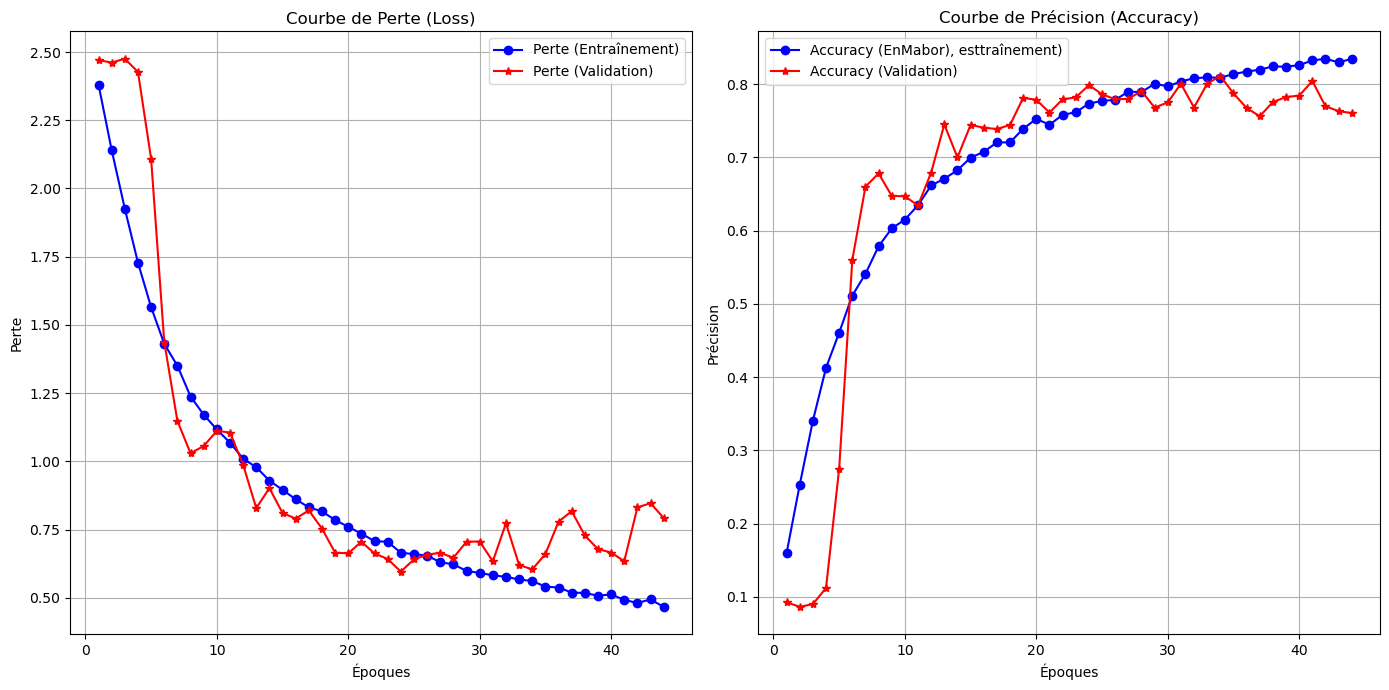

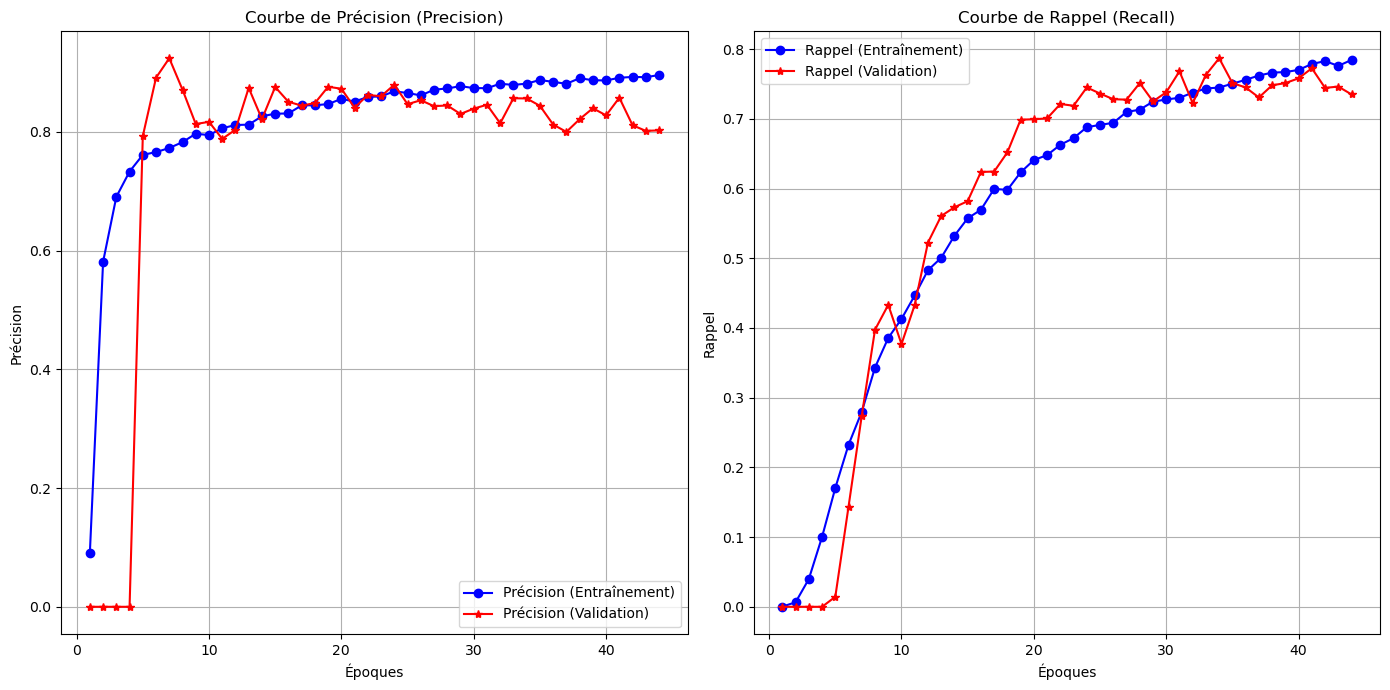

In [19]:
# (Assurez-vous que 'model', 'train', 'val', et 'param' sont définis)

# 1. Exécutez l'entraînement ET récupérez l'historique
print("Lancement de l'entraînement...")
validation_eval, trained_model, history = compile_and_fit(model, train, val, param)

print("\nÉvaluation finale sur le set de validation :", validation_eval)

# 2. Tracez les graphiques
print("Affichage des courbes d'apprentissage...")
plot_training_history(history)

### Fit tuning des hyperparamètres.

Après avoir défini les hyperparamètres modifiables et vérifier que les fonctions fonctionnent, il est temps de lancer l'optimisation des hyperparamètres. Pour cela je vous invite à utiliser Optuna [[3]](https://optuna.readthedocs.io/en/stable/index.html) qui a plusieurs fonctionnalités:
*   Une visualisation facilitée.
*   Un suivi de l'avancement de l'optimisation.
*   Une possibilité de reprendre l'optimisation sans reprendre depuis le début si un problème arrive durant le traitement.

 <font color=" Darkblue"> **Tips:** Essayez de lancer l'optimisation pendant le TP pour voir si il fonctionne et arretez le. Lancez le pour de bon à la fin de la séance ou pendant la semaine car cela va prendre plusieurs heures, voir plusieurs jours. </font>

 <font color="orange"> **Note anti-plagiat:** L'optimisation doit avoir une random seed fixe et différente pour chaque groupe. </font>

 Merci de justifier vos plages de valeurs et faite un résumé sous forme de tableau :
 > **Ecrire votre texte ici.**


| Hyperparamètre | Meilleure valeur (à compléter) |     Plage explorée     |    Step    | Type de la plage                    |
| :------------- | :----------------------------: | :--------------------: | :--------: | :---------------------------------- |
| activation     |           ex. `relu`           | {`relu`, `leaky_relu`} |      –     | Catégorielle (liste finie)          |
| conv_filters   |            ex. `64`            |    {16, 32, 64, 128}   | – (catég.) | Discrète, puissances de deux        |
| ds_filters_1   |            ex. `64`            |    {16, 32, 64, 128}   | – (catég.) | Discrète, puissances de deux        |
| ds_filters_2   |            ex. `64`            |    {16, 32, 64, 128}   | – (catég.) | Discrète, puissances de deux        |
| dense_units    |            ex. `64`            |    {16, 32, 64, 128}   | – (catég.) | Discrète, puissances de deux        |
| dropout_rate   |            ex. `0.3`           |       [0.1, 0.5]       |   Continu  | Float uniforme (régularisation)     |
| BATCH_SIZE     |            ex. `64`            |    {16, 32, 64, 128}   | – (catég.) | Catégorielle, puissances de deux    |
| kernell        |            3 (fixé)            |           {3}          |      –     | Fixe (non optimisé, choix a priori pour contraintes embarqués) |


In [20]:
import optuna

/home/zebre/miniforge3/envs/tf-ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
'''
def objective(trial):
    # 1) Tirage des hyperparamètres
    param_model = {
        "activation"  : trial.suggest_categorical("activation", ["relu", "leaky_relu"]),
        "conv_filters": trial.suggest_categorical("conv_filters", [16, 32, 64, 128]), # on reste en puissance de dexu pour simplififer implémentation
        "ds_filters_1": trial.suggest_categorical("ds_filters_1", [16, 32, 64, 128]),
        "ds_filters_2": trial.suggest_categorical("ds_filters_2", [16, 32, 64, 128]),
        "dense_units" : trial.suggest_categorical("dense_units", [16, 32, 64, 128]),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),
        "kernell"     :  3 # Fixé pour simplififer la zone de recherche des hyperparamètre en accord avec littérature
    }
    param_training = {
        "BATCH_SIZE": trial.suggest_categorical("BATCH_SIZE", [16, 32, 64, 128]),
    }

    # 2) Création + taille du modèle
    model = create_model(param_model, INPUT_SHAPE, NUM_CLASSES)
    size = total_param(model)
    trial.set_user_attr("Size", size)

    # 3) Entraînement + métriques
    metrics, _, _ = compile_and_fit(model, train, val, param_training, verbose=0)
    val_acc = metrics[1]  # adapte si besoin

    # 4) On renvoie 2 objectifs : (à max, à min)
    return val_acc, size   # 1er objectif = accuracy, 2e = taille


study_name = "Benarib~Hanni-Tuning-embedded"
storage_name = f'/home/zebre/Bureau/eddge_computing/Edge_computing/model/{study_name}.db' #Chemin à créer dans votre drive

storage_url = f"sqlite:///{storage_name}"


study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="Benarib~Hanni-Tuning-embedded",
    storage=storage_url,
    sampler=optuna.samplers.TPESampler(seed=SEED),
    load_if_exists=True,
)
'''

'\ndef objective(trial):\n    # 1) Tirage des hyperparamètres\n    param_model = {\n        "activation"  : trial.suggest_categorical("activation", ["relu", "leaky_relu"]),\n        "conv_filters": trial.suggest_categorical("conv_filters", [16, 32, 64, 128]), # on reste en puissance de dexu pour simplififer implémentation\n        "ds_filters_1": trial.suggest_categorical("ds_filters_1", [16, 32, 64, 128]),\n        "ds_filters_2": trial.suggest_categorical("ds_filters_2", [16, 32, 64, 128]),\n        "dense_units" : trial.suggest_categorical("dense_units", [16, 32, 64, 128]),\n        "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),\n        "kernell"     :  3 # Fixé pour simplififer la zone de recherche des hyperparamètre en accord avec littérature\n    }\n    param_training = {\n        "BATCH_SIZE": trial.suggest_categorical("BATCH_SIZE", [16, 32, 64, 128]),\n    }\n\n    # 2) Création + taille du modèle\n    model = create_model(param_model, INPUT_SHAPE, NUM_CLASSES)

In [22]:
# study.optimize(objective, n_trials=300)

In [23]:
# Load the existing study
study_name = "Benarib~Hanni-Tuning-embedded"
storage_name = '/home/zebre/Bureau/eddge_computing/Edge_computing/model/Benarib~Hanni-Tuning-embedded.db'
storage_url = f"sqlite:///{storage_name}"

study = optuna.load_study(
    study_name=study_name,
    storage=storage_url
)


## Résultat et discussion

<font color=" Darkred"> Progression du TP après cette partie (environ 3h): </font>  
![84%](https://progress-bar.dev/84)


### Export du modèle

Merci d'exporter le meilleur modèle et l'envoyer avec le jupyter notebook et la base de données d'entraînement. Lors de l'exportation d'un modèle, il est recommandé d'utiliser la base de donnée d'entrainement, et de validation.

 <font color="green">*Cette partie du code est complète, vous n'avez pas besoin de la modifier.* </font>

Nombre de modèles sur le front de Pareto : 16
Accuracy Max Absolue : 0.8894
Accuracy Acceptable  : >= 0.8694

=== RÉSULTAT DE LA SÉLECTION ===
Modèle choisi (ID Trial : 137)
 -> Accuracy : 0.8763 (Perte de 0.0131)
 -> Taille   : 16748.0 params
 -> Gain taille vs Max Accuracy : -60.75% de paramètres !

=== MEILLEUR MODÈLE SÉLECTIONNÉ ===
   Accuracy attendue : 0.8763
   Taille (params)   : 16748.0
   Params: 
    -activation: relu
    -conv_filters: 128
    -ds_filters_1: 32
    -ds_filters_2: 128
    -dense_units: 32
    -dropout_rate: 0.42214288574539405
    -BATCH_SIZE: 16
-------------------------------------
Epoch 1/100
584/584 [==============================] - 6s 7ms/step - loss: 2.2088 - accuracy: 0.2211 - precision: 0.6182 - recall: 0.0073 - val_loss: 2.1713 - val_accuracy: 0.2250 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
584/584 [==============================] - 4s 7ms/step - loss: 1.7168 - accuracy: 0.3997 - precision: 0.6959 - recall: 0.1163 - val_los

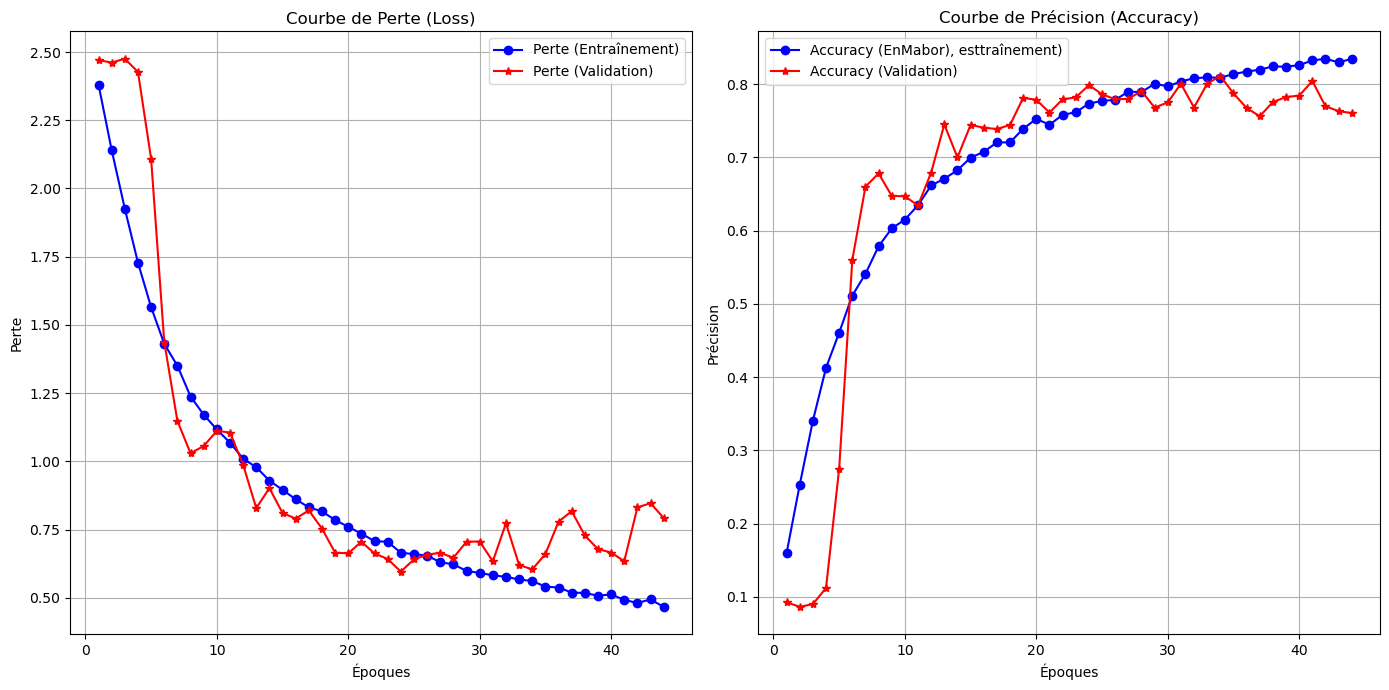

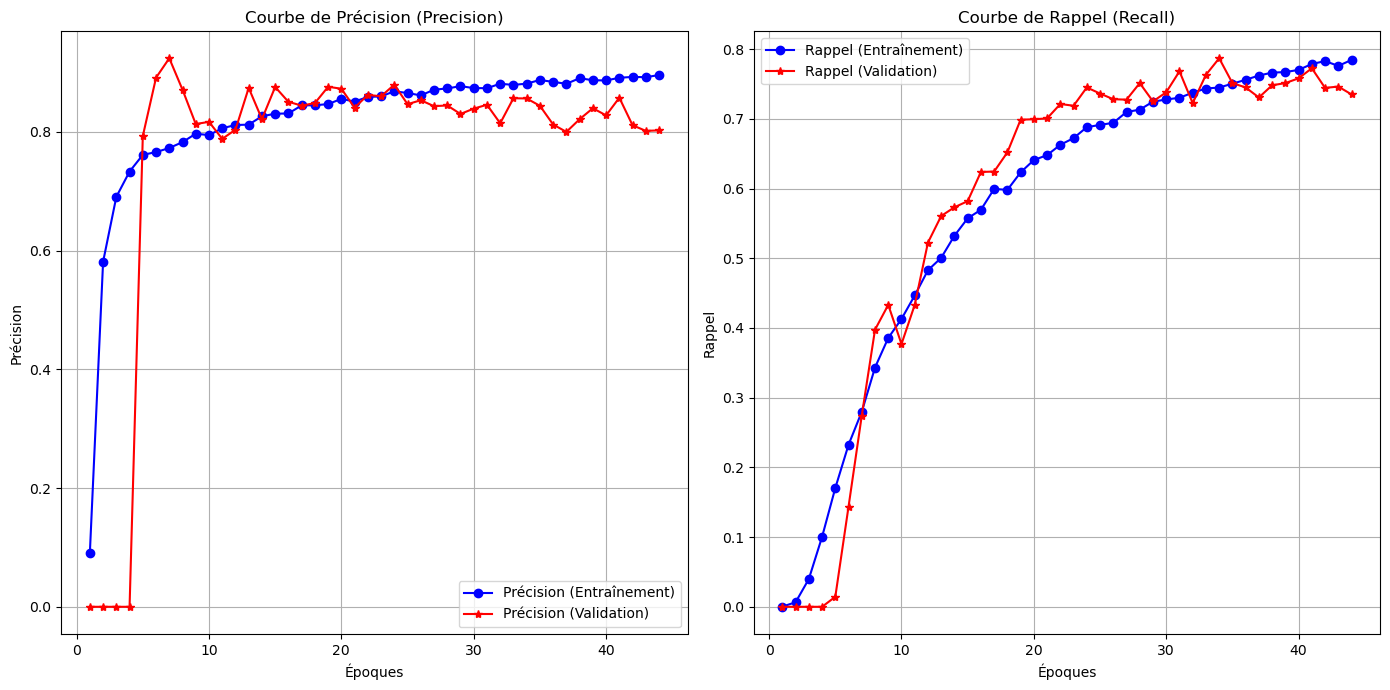

Modèle sauvegardé sous : /home/zebre/Bureau/eddge_computing/Edge_computing/model/Hanni_Benarib_model.keras


In [24]:
import joblib

# 1. Chargement de l'étude
storage_url_fixed = f"sqlite:///{storage_name.replace('sqlite:///', '')}"
study = optuna.load_study(storage=storage_url_fixed, study_name=study_name)

# 2. Récupération du Front de Pareto (Liste des meilleurs compromis)
best_trials = study.best_trials

print(f"Nombre de modèles sur le front de Pareto : {len(best_trials)}")

# 3. Trouver la meilleure Accuracy absolue sur le front de Pareto
# (values[0] = accuracy, values[1] = size)
max_accuracy_trial = max(best_trials, key=lambda t: t.values[0])
max_acc = max_accuracy_trial.values[0]

# 4. Définir la marge de tolérance (0.01 = 1%)
TOLERANCE = 0.02
acc_threshold = max_acc - TOLERANCE

print(f"Accuracy Max Absolue : {max_acc:.4f}")
print(f"Accuracy Acceptable  : >= {acc_threshold:.4f}")

# 5. Filtrer les candidats (ceux qui sont assez précis)
candidates = [t for t in best_trials if t.values[0] >= acc_threshold]

# 6. Sélectionner le plus petit parmi les candidats
# On trie par taille (values[1]) croissant et on prend le premier
chosen_trial = sorted(candidates, key=lambda t: t.values[1])[0]

# --- Affichage du gain ---
size_max_acc = max_accuracy_trial.values[1]
size_chosen  = chosen_trial.values[1]
reduction = (1 - size_chosen / size_max_acc) * 100

print("\n=== RÉSULTAT DE LA SÉLECTION ===")
print(f"Modèle choisi (ID Trial : {chosen_trial.number})")
print(f" -> Accuracy : {chosen_trial.values[0]:.4f} (Perte de {(max_acc - chosen_trial.values[0]):.4f})")
print(f" -> Taille   : {size_chosen} params")
print(f" -> Gain taille vs Max Accuracy : -{reduction:.2f}% de paramètres !")

print("\n=== MEILLEUR MODÈLE SÉLECTIONNÉ ===")
print(f"   Accuracy attendue : {chosen_trial.values[0]:.4f}")
print(f"   Taille (params)   : {chosen_trial.values[1]}")
print("   Params: ")
for key, value in chosen_trial.params.items():
    print(f"    -{key}: {value}")
print("-------------------------------------")

# 7. Recréation et Réentraînement du modèle choisi
# On utilise les hyperparamètres du "chosen_trial"
model = create_model(chosen_trial.params, INPUT_SHAPE, NUM_CLASSES)

# Concaténation Train + Val pour l'entraînement final (Bonne pratique !)
X_full = np.concatenate((X_train, X_val))
y_full = np.concatenate((y_train, y_val))

# Recréation du dataset complet
train_and_val = tf.data.Dataset.from_tensor_slices((X_full, y_full))
train_and_val = train_and_val.shuffle(1500, reshuffle_each_iteration=True)
# Attention : Assure-toi que le BATCH_SIZE est bien dans les params ou fixe-le
batch_size_final = chosen_trial.params.get("BATCH_SIZE", 32) 
train_and_val = train_and_val.batch(batch_size_final, drop_remainder=True)

# Entraînement final
# Note: "val" ici sert juste de témoin, car le modèle apprend déjà sur ces données via train_and_val
# Idéalement, on devrait évaluer sur un jeu de TEST jamais vu.
validation_evaluation_post_optuna, global_model_post_optuna, history_post_optuna = compile_and_fit(
    model, 
    train_and_val, 
    val, 
    chosen_trial.params, 
    verbose=1 # Mets 1 pour voir que ça tourne
)

print("Affichage des courbes d'apprentissage...")
plot_training_history(history)


# 4. Sauvegarde
# IMPORTANT : Pour Keras/TensorFlow, évite joblib. Utilise la méthode native .save()
# Le format .keras est le nouveau standard, ou .h5
save_path = '/home/zebre/Bureau/eddge_computing/Edge_computing/model/Hanni_Benarib_model.keras'
global_model_post_optuna.save(save_path)
print(f"Modèle sauvegardé sous : {save_path}")

### Dépôt sur Kaggle

Il est temps de soumettre vos résultats sur Kaggle. Qu'en pensez vous, êtes vous satisfait de vos performances ? Est-ce que vous vous attendiez à ces performances ?

 <font color=" Darkblue"> **Tips:** Le format d'envoie et des tutoriels sont disponibles sur la page du concours. </font>

 <font color="orange"> **Note anti-plagiat:** Il est impossible que le fichier que vous allez déposer soit le même qu'un autre binôme. Le fichier sera regénérer lors de la correction et doit être similaire avec celui déposé. </font>

A la fin du projet, merci d'envoyer avec les autres fichiers ce fichier Kaggle avec comme nom **NOM1~NOM2_submission.csv**.

> **Ecrire votre texte ici.**

In [25]:
#Ici, tous le code est à faire. Normalement, tous a déjà été codé ou est facilement trouvable sur internet et sur le site de la compétition !

### Visualisation des résultats

Ici tous le code a déjà été fait. Il faut par contre commenter les résultats et les performances que vous avez obtenu et l'utilité de chaque figure.

 #### Matrice de confusion

 <font color="green">*Cette partie du code est complète, vous n'avez pas besoin de la modifier.* </font>

 > **Ecrire votre texte ici.**

25/25 [==============================] - 0s 4ms/step


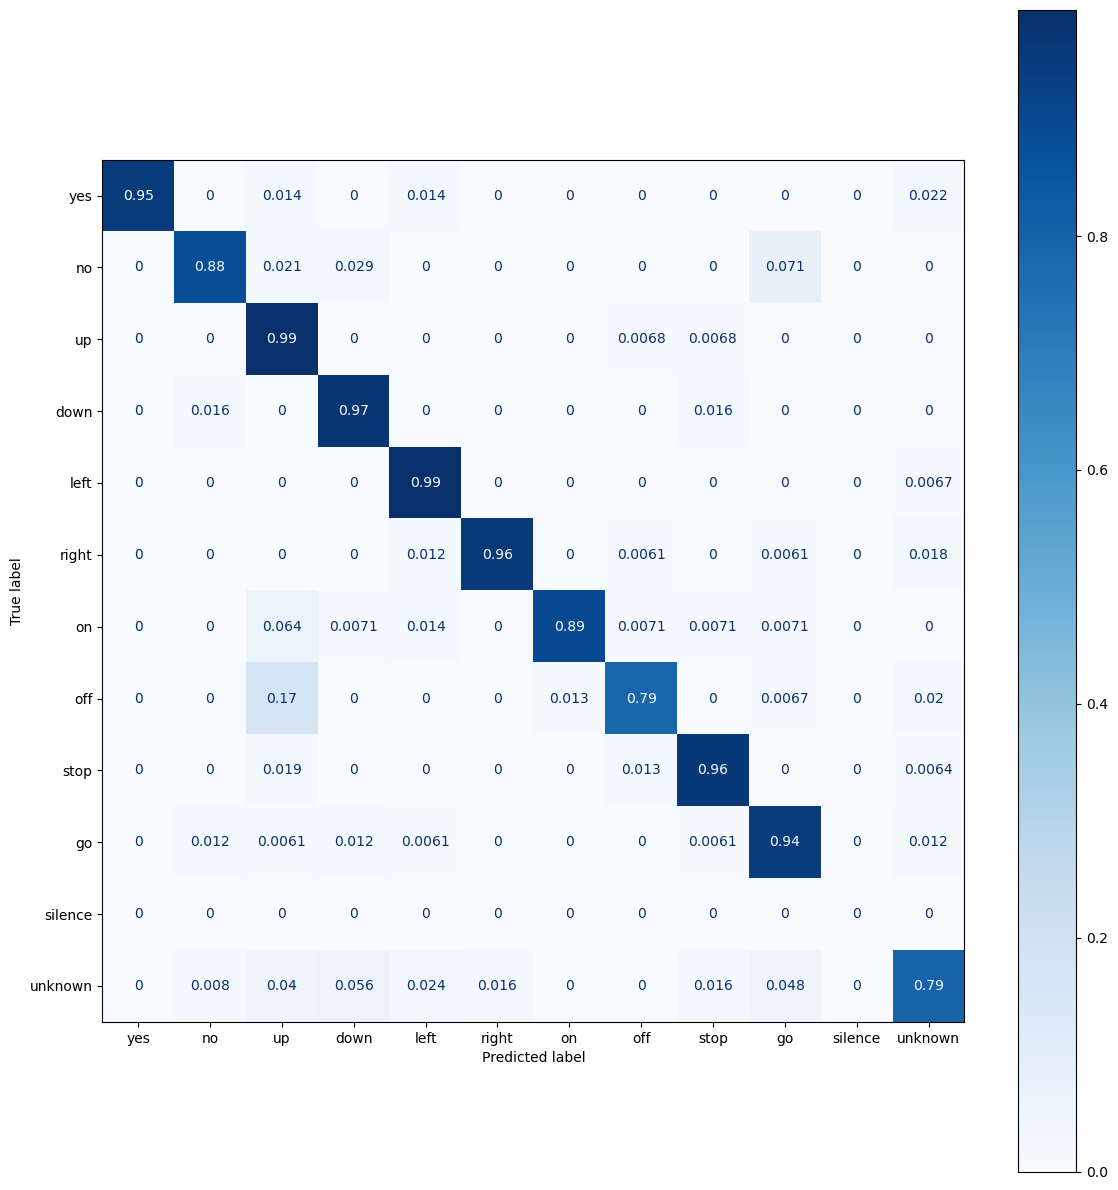

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

# (re)load study if needed
study = optuna.load_study(storage=storage_url, study_name=study_name)

# Predictions from the model on the validation dataset
y_prob = global_model_post_optuna.predict(val)
y_pred = y_prob.argmax(axis=1)

# Build reference labels from the tf.data Dataset
ds_labels = []
for images, labels in val.unbatch():
    ds_labels.append(labels)
y_ref = np.array(ds_labels).argmax(axis=1)

# Label names (order must match the numeric label indices)
label_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "silence", "unknown"]

# Ensure the confusion matrix includes all classes (even if some are absent in y_ref/y_pred)
all_labels = list(range(len(label_names)))

# Draw confusion matrix — pass `labels` so ticks match `display_labels`
ConfusionMatrixDisplay.from_predictions(
    y_ref,
    y_pred,
    labels=all_labels,
    display_labels=label_names,
    cmap='Blues',
    normalize='true',
    ax=plt.subplots(figsize=(12, 12))[1]
)
plt.tight_layout()

#### Résultat du Fit-tuning

 <font color="green">*Cette partie du code est complète, vous n'avez pas besoin de la modifier.* </font>

 > **Ecrire votre texte ici.**

In [27]:
plt.figure(figsize=(12,12))
optuna.visualization.plot_optimization_history(
    study,
    target=lambda t: t.values[0],  # On récupère la 1ère valeur retournée par ta fonction objective
    target_name="Accuracy"         # Nom affiché sur l'axe Y
)

<Figure size 1200x1200 with 0 Axes>

In [28]:
optuna.visualization.plot_optimization_history(
    study,
    target=lambda t: t.values[1],  # On récupère la 2ème valeur retournée par ta fonction objective
    target_name="Model Size (numbers of parmeters)"         # Nom affiché sur l'axe Y
)

In [29]:
optuna.visualization.plot_slice(
    study,
    target=lambda t: t.values[0],  # On récupère la 1ère valeur retournée par ta fonction objective
    target_name="Accuracy"         # Nom affiché sur l'axe Y
)

In [30]:
optuna.visualization.plot_optimization_history(
    study,
    target=lambda t: t.values[1],  # On récupère la 2ème valeur retournée par ta fonction objective
    target_name="Model Size (numbers of parmeters)"         # Nom affiché sur l'axe Y
)

#### Influence des hyperparamètres sur les performances

 <font color="green">*Cette partie du code est complète, vous n'avez pas besoin de la modifier.* </font>

 > **Ecrire votre texte ici.**

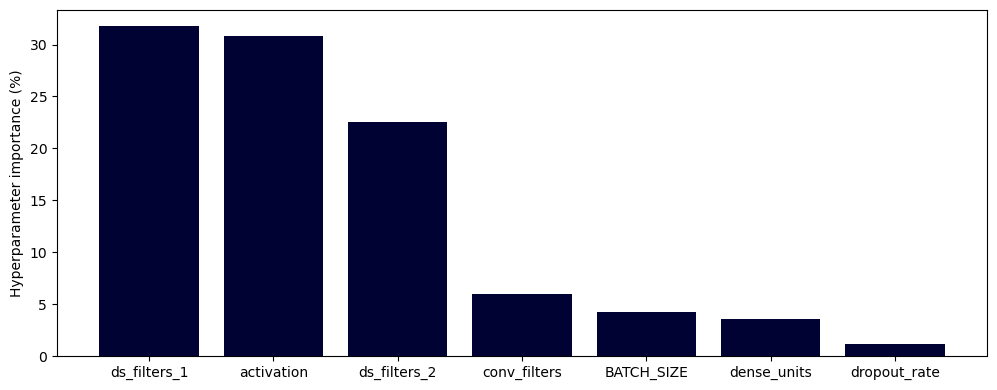

In [31]:
result = optuna.importance.get_param_importances(study,target=lambda t: t.values[0])
plt.figure(figsize=(12, 4.5), dpi=100)
names = list(result.keys())
values = list(result.values())

plt.bar(range(len(result)), np.array(values)*100, tick_label=names, color='#000233')
plt.ylabel("Hyperparameter importance (%)")
plt.show()

#### Influence des hyperparamètres sur le temps de calcul

 <font color="green">*Cette partie du code est complète, vous n'avez pas besoin de la modifier.* </font>

 > **Ecrire votre texte ici.**

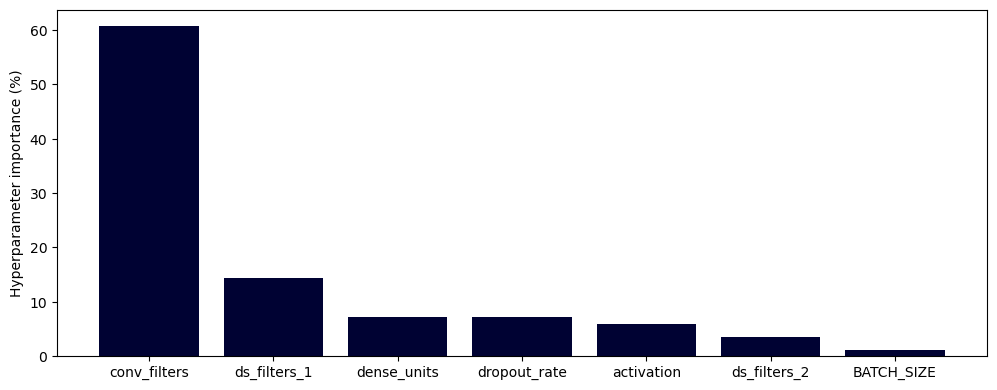

In [32]:
result = optuna.importance.get_param_importances(study, target=lambda t: t.duration.total_seconds())
plt.figure(figsize=(12, 4.5), dpi=100)
names = list(result.keys())
values = list(result.values())

plt.bar(range(len(result)), np.array(values)*100, tick_label=names, color='#000233')
plt.ylabel("Hyperparameter importance (%)")
plt.show()

#### Frontière de Pareto [[4]](https://fr.wikipedia.org/wiki/Optimum_de_Pareto)

 <font color="green">*Cette partie du code est complète, vous n'avez pas besoin de la modifier.* </font>

 > **Ecrire votre texte ici.**

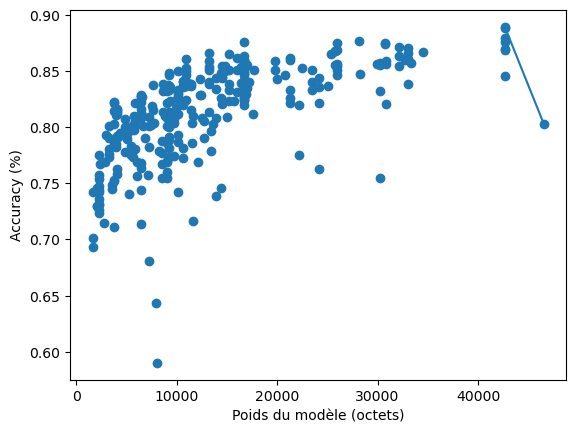

In [33]:
# NOTE: pandas and plt are already imported earlier in the notebook (do not re-import here).
# This cell makes the trials dataframe usage robust for single- and multi-objective studies.

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=True):
    # From https://sirinnes.wordpress.com/2013/04/25/pareto-frontier-graphic-via-python/
    '''Pareto frontier selection process'''
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxY)
    pareto_front = [sorted_list[0]]
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)

    '''Plotting process'''
    plt.scatter(Xs, Ys)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y)
    plt.xlabel("Poids du modèle (octets)")
    plt.ylabel("Accuracy (%)")
    plt.show()

# Get trials dataframe
df = study.trials_dataframe()

# Determine objective column (support single- and multi-objective naming)
if 'value' in df.columns:
    y_col = 'value'
elif 'values_0' in df.columns:
    y_col = 'values_0'
elif 'values' in df.columns:
    y_col = 'values'
else:
    raise KeyError(f"No objective value column found in trials_dataframe. Available columns: {list(df.columns)}")

# Determine user_attr column for Size
if 'user_attrs_Size' in df.columns:
    x_col = 'user_attrs_Size'
else:
    # try to find a user_attrs column containing 'Size' or take any user_attrs column
    candidates = [c for c in df.columns if 'user_attrs' in c and 'Size' in c]
    if candidates:
        x_col = candidates[0]
    else:
        ua = [c for c in df.columns if c.startswith('user_attrs_')]
        if ua:
            x_col = ua[0]
        else:
            raise KeyError(f"No user_attrs column found in trials_dataframe. Available columns: {list(df.columns)}")

# Prepare data (drop rows with missing values)
plot_df = df[[x_col, y_col]].dropna()
Xs = plot_df[x_col].astype(float).tolist()
Ys = plot_df[y_col].astype(float).tolist()

plot_pareto_frontier(Xs, Ys)

## Allégement du modèle post-optimisation

Dans cette dernière partie, nous allons nous intéresser à l'influence des performances lorsque le modèle est allégé. Dans des appareils embarqués, il est nécessaire de trouver un compromis entre la performance du modèle, son poids, et la quantité d'opération.

Au vue du nombre de séances, nous allons nous intéressé ici qu'au poids du système.

Pour cela, vous allez essayé de réduire le poids du meilleur modèle obtenu, puis avoir un regard critique sur les performances à chaque modification.

Voici les techniques d'allégement à essayer:
  - **La quantification**: Réduire le nombre d'octets des paramètres du modèles et les convertir en entiers [[5]](https://www.tensorflow.org/lite/performance/post_training_quantization).
  - **L'élagage**: Supprimer les modèles qui ont un impact mineur sur les prédictions [[6]](https://www.tensorflow.org/model_optimization/guide/pruning/pruning_with_keras).
  - **Le clustering**: Regrouper les poids de chaque couche dans un modèle en un nombre prédéfini de clusters, puis en partageant les valeurs centroïdes pour les poids appartenant à chaque cluster individuel [[7]](https://www.tensorflow.org/model_optimization/guide/clustering/clustering_example).
  - **La décimation** : Réduire le nombre d'entrée.

<font color=" Darkred"> Progression du TP après cette partie (environ 4h):

Essayez d'avoir la meilleure accuracy avec un poids maximum inférieur à 75 KB.

 <font color=" Darkblue"> **Tips:**  Des tutoriels sont disponibles sur les liens attachés au techniques d'allégement. </font>

 > **Ecrire votre texte ici.**

Pour cette partie nous sommes partis nous avons suivie les conseils données en [[5]](https://www.tensorflow.org/lite/performance/post_training_quantization). 

Pour la quantification. Notre modèle étant optimisé via otpuna aux niveaus de ses hyperparamètres, notre architecture ayant pour but d'être porté sur FPGA (cible difficile à programmer) et notre dataset n'étant pas représentatif de nos données, nous nous sommes cantonés à une quantification en float16 ppur commencer. 
![Screenshot from 2025-11-24 01-39-04.png](<attachment:Screenshot from 2025-11-24 01-39-04.png>)
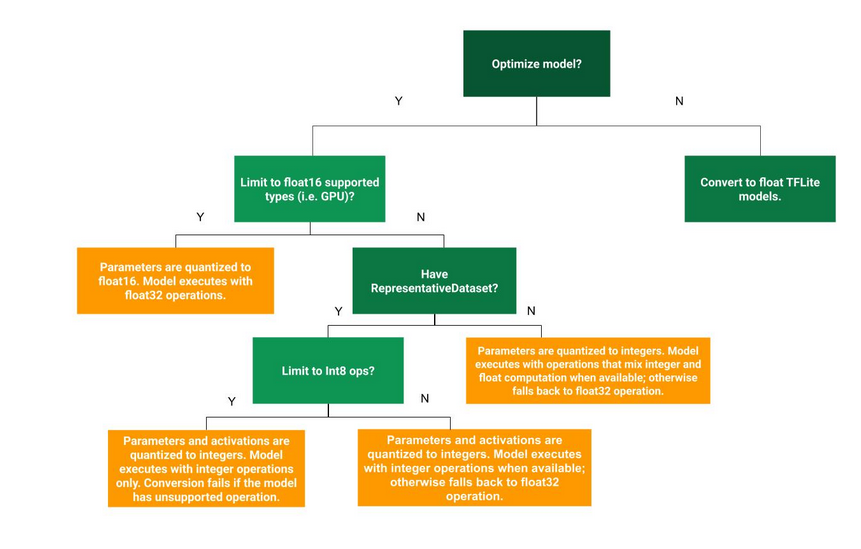

Tensor Flow Lite permet de réaliser cette conversion en: 

    - float 16 (réduit de moitié la taille du modèle)
    - int 8
    - int 4 

Au regarde de l'application que nous allonns réaliser, nous devons choisir quelle type de quantififcation sera la plus intéressante. Pour cela nous devons étuider les avantages et inconvénients de chacun et leur impact sur les performances de notre modèle.



Les avanatges du float 16  sont les suivants :

    - Réduction de la taille du modèle de moitié (poids et activation réduit à 16 bits)
    - Pert d'accuracy minimale
    - Rend le calul possible sur architecyure GPU 

Les désavantages du float 16 sont:

    - Ne réduit pas la latence autant qu'une quantificatio avec calcul en virgule fixe.
    By default, a float16 quantized model will "dequantize" the weights values to float32 when run on the CPU. (Note that the GPU delegate will not perform this dequantization, since it can operate on float16 data.)


Pour aller plus loin dans le projet sur la quantification, et voire laquelle serait la plus intéressante pour un bon rapport perfomance/implémentation et embarquabilité sur cible, il nous faut observer ce que donne les résultats de notre modèle avec cette simple quantification, sans détails supplémentaire. Pour cela nous avons rédigé une petite focntion ci dessous pour quantifier nos données ainsi que notre réseaux.

In [34]:
def fake_quantize(x, bits, frac_bits):
    """
    Simule un format fixe signé Q(1.(bits-1)) avec 'frac_bits' bits de fraction.
    bits = largeur totale (ex: 8) ; frac_bits ~ 7 → Q1.7
    """
    x = x.astype(np.float32)
    scale = 2 ** frac_bits

    qmin = -2 ** (bits - 1)
    qmax =  2 ** (bits - 1) - 1

    x_scaled = np.round(x * scale)
    x_clipped = np.clip(x_scaled, qmin, qmax)
    x_dequant = x_clipped / scale
    return x_dequant.astype(np.float32)

De plus voici un lot de fonction pour quantifier en int et déquantifier pour réaliser les comparaisons

In [35]:
def quantize_to_int(x, bits=8, frac_bits=7):
    scale = 2 ** frac_bits
    qmin, qmax = -(2**(bits-1)), 2**(bits-1) - 1

    x_int = np.round(x * scale).astype(np.int32)
    x_int = np.clip(x_int, qmin, qmax).astype(np.int8)  # ou int16 si besoin
    return x_int, scale

def dequantize_from_int(x_int, scale):
    return x_int.astype(np.float32) / scale

def fake_quantize(x, bits=8, frac_bits=7):
    x_int, scale = quantize_to_int(x, bits, frac_bits)
    return dequantize_from_int(x_int, scale)



Etant donné que nous avons pour projet d'essayer d'embarqué l modèle sur carte FPGA, nous devons regarder comment effectuer la quantification des données également. Ce que nosu faisons ci dessous.

In [36]:
# Évaluer modèle de référence et les versions quantifiées
reference_results = model.evaluate(X_val, y_val)
Q1_14_results = model.evaluate(fake_quantize(X_val, bits=16, frac_bits=14), y_val)
Q1_6_results = model.evaluate(fake_quantize(X_val, bits=8, frac_bits=7), y_val)

# Fonction sûre pour éviter division par zéro / types incompatibles
def _safe_ratio(num, den):
	try:
		den_f = float(den)
		num_f = float(num)
		return num_f / den_f if den_f != 0.0 else np.nan
	except Exception:
		return np.nan

precision_loss_Q1_6 = [_safe_ratio(q, r) for q, r in zip(Q1_6_results, reference_results)]
precision_loss_Q1_14 = [_safe_ratio(q, r) for q, r in zip(Q1_14_results, reference_results)]

print("Résultats (quantifié / référence) — ordre: [loss, accuracy, precision, recall]")
print("Résultats en Q1.6 (acc, precision):", precision_loss_Q1_6)
print("Résultats en Q1.14 (acc, precision):", precision_loss_Q1_14)


52/52 [==============================] - 0s 6ms/step - loss: 0.2210 - accuracy: 0.9182 - precision: 0.9427 - recall: 0.9067
Résultats (quantifié / référence) — ordre: [loss, accuracy, precision, recall]
Résultats en Q1.6 (acc, precision): [1.0068040447601292, 0.9980249875419899, 0.9980738119452814, 0.9993324334783625]
Résultats en Q1.14 (acc, precision): [35.3134422961767, 0.08624094737368562, 0.08400702270129022, 0.08744993333203262]


In [37]:
# X_val : MFCC float32, y_val labels
X_val_q = fake_quantize(X_val, bits=8, frac_bits=7)
float_metrics = model.evaluate(X_val,   y_val, verbose=0)
quant_in_metrics = model.evaluate(X_val_q, y_val, verbose=0)
print("Float  :", float_metrics)
print("In 8bQ :", quant_in_metrics)
print("Performance lost on Accuracy  ",(1-(quant_in_metrics[1]/float_metrics[1])))
print("Performance lost on Precision  ",(1-(quant_in_metrics[2]/float_metrics[2])))
print("Performance lost on Recall  ",(1-(quant_in_metrics[3]/float_metrics[3])))


Float  : [0.21948188543319702, 0.9200484752655029, 0.9445145130157471, 0.9073289036750793]
In 8bQ : [0.22097525000572205, 0.9182313680648804, 0.9426952004432678, 0.9067232012748718]
Performance lost on Accuracy   0.001975012458010128
Performance lost on Precision   0.0019261880547185584
Performance lost on Recall   0.0006675665216374638


On conserve de bonne perfomances en int16 qui est choix permis par l'architecture de nos DSP (Xilnx DSP48E2) qui permettent de gérer facilement des mult 16*27 dans acc 43 bits donc des MAC (en termes de tailles):[48] =  [16]x[28] + [43]

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def make_quantized_copy(model, bits=16, frac_bits=7):
    # clone archi
    q_model = tf.keras.models.clone_model(model)
    q_model.build(model.input_shape)

    # copie + quantif des poids
    w_float = model.get_weights()
    w_q = [fake_quantize(w, bits=bits, frac_bits=frac_bits) for w in w_float]
    q_model.set_weights(w_q)
    return q_model

# 1) entrées quantifiées
X_val_q = fake_quantize(X_val, bits=8, frac_bits=7)

for i, w in enumerate(model.get_weights()):
    print(f"W{i}: min={w.min():.3f}, max={w.max():.3f}, max_abs={np.max(np.abs(w)):.3f}")


# 2) modèle aux poids quantifiés
q_model = make_quantized_copy(model, bits=8, frac_bits=7)

# 3) prédictions sans compile/evaluate
logits = q_model(X_val_q, training=False).numpy()   # [N, num_classes]
y_pred = np.argmax(logits, axis=1)

logits = q_model(X_val_q, training=False).numpy()   # [N, num_classes]
y_pred = np.argmax(logits, axis=1)

# si y_val est one-hot : (shape (N, C))
if y_val.ndim == 2:
    y_true = np.argmax(y_val, axis=1)
else:
    y_true = y_val

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")

print("Quant in+weights -> acc/prec/rec :", acc, prec, rec)


W0: min=-0.586, max=0.585, max_abs=0.586
W1: min=-0.222, max=0.167, max_abs=0.222
W2: min=0.735, max=1.750, max_abs=1.750
W3: min=-0.727, max=0.635, max_abs=0.727
W4: min=0.000, max=0.174, max_abs=0.174
W5: min=0.000, max=0.042, max_abs=0.042
W6: min=-0.748, max=0.480, max_abs=0.748
W7: min=-0.854, max=0.822, max_abs=0.854
W8: min=-0.432, max=1.034, max_abs=1.034
W9: min=0.665, max=1.145, max_abs=1.145
W10: min=-0.666, max=0.979, max_abs=0.979
W11: min=0.151, max=3.111, max_abs=3.111
W12: min=0.256, max=4.939, max_abs=4.939
W13: min=-0.650, max=0.444, max_abs=0.650
W14: min=-0.963, max=0.802, max_abs=0.963
W15: min=-0.545, max=0.711, max_abs=0.711
W16: min=0.417, max=2.238, max_abs=2.238
W17: min=-1.100, max=0.231, max_abs=1.100
W18: min=0.000, max=2.221, max_abs=2.221
W19: min=0.000, max=0.838, max_abs=0.838
W20: min=-1.320, max=1.072, max_abs=1.320
W21: min=-0.215, max=0.377, max_abs=0.377
W22: min=-4.626, max=0.550, max_abs=4.626
W23: min=-5.046, max=-0.063, max_abs=5.046


2025-12-09 09:18:50.861106: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.67GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-09 09:18:50.970982: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.67GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


Quant in+weights -> acc/prec/rec : 0.28346456692913385 0.7685830634351501 0.28661163636958426


Avec Q1.7 global, on impose une échelle fixe scale = 2^7. Comme beaucoup de tenseurs ont des poids jusqu’à des valeurs entre 4 et 10 (W11–W23), tout ce qui est >~1 est clippé à ±0.99 donc on perds une grosse partie de l’info, d’où l’accuracy qui tombe à ~0.24.

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def fake_quantize_weight_per_tensor(w, bits=16):
    qmax = 2**(bits-1) - 1
    max_abs = np.max(np.abs(w)) 
    scale = qmax / max_abs          # échelle spécifique à CE tenseur
    w_int = np.round(w * scale).astype(np.int32)
    w_int = np.clip(w_int, -qmax-1, qmax).astype(np.int8)
    w_deq = w_int.astype(np.float32) / scale
    return w_deq, scale             # garde scale si tu veux l'utiliser plus tard

def make_quantized_copy(model, bits=8):
    q_model = tf.keras.models.clone_model(model)
    q_model.build(model.input_shape)

    w_float = model.get_weights()
    w_q = [fake_quantize_weight_per_tensor(w, bits=bits)[0] for w in w_float]
    q_model.set_weights(w_q)
    return q_model


X_val_q = fake_quantize(X_val, bits=8, frac_bits=7)  # pour les MFCC, Q1.7 va bien
q_model = make_quantized_copy(model, bits=8)

logits = q_model(X_val_q, training=False).numpy()
y_pred = np.argmax(logits, axis=1)
y_true = np.argmax(y_val, axis=1) if y_val.ndim == 2 else y_val

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("Quant in+weights -> acc/prec/rec :", acc, prec, rec)


Quant in+weights -> acc/prec/rec : 0.8903694730466384 0.9008425234697931 0.8918454168018655


Ici pour résoudre ce problème nous avons tenté une quantif “par tenseur” qui évalue au contraire scale_i = qmax / max_abs_i pour chaque W_i, donc chaque matrice utilise toute la dynamique int8 sans être saturée. On as donc (presque) les mêmes poids que le modèle float, juste arrondis → ça explique la remonté r à ≈0.888/0.895/0.889, quasi identique au modèle initial.

In [40]:
def quantize_weight_pow2(w, bits=8):
    """
    Quantif symétrique par tenseur avec scale = 2^k (k entier)
    Retourne : w_deq (float32), scale (float)
    """
    qmax = 2**(bits-1) - 1
    max_abs = np.max(np.abs(w)) + 1e-8

    # scale idéal puis projection sur la puissance de 2 la plus proche
    ideal_scale = qmax / max_abs
    k = int(np.round(np.log2(ideal_scale)))
    scale = 2.0**k

    # on s'assure qu'on ne dépasse pas qmax
    if max_abs * scale > qmax:
        scale = qmax / max_abs

    w_int = np.round(w * scale).astype(np.int32)
    w_int = np.clip(w_int, -qmax-1, qmax).astype(np.int16 if bits > 8 else np.int8)
    w_deq = w_int.astype(np.float32) / scale
    return w_deq, scale

def make_quantized_copy_pow2(model, bits=16):
    q_model = tf.keras.models.clone_model(model)
    q_model.build(model.input_shape)

    w_float = model.get_weights()
    scales  = []
    w_q = []
    for w in w_float:
        w_deq, s = quantize_weight_pow2(w, bits=bits)
        w_q.append(w_deq)
        scales.append(s)   # tu peux les logguer pour le FPGA
    q_model.set_weights(w_q)
    return q_model, scales

# --- test complet entrées int16 + poids int8/int16 (scale = 2^k) ---

# 1) MFCC quantifiées (par ex. Q3.12 -> frac_bits=12)
X_val_q = fake_quantize(X_val, bits=16, frac_bits=12)

# 2) modèle aux poids quantifiés puissance de 2
q_model, weight_scales = make_quantized_copy_pow2(model, bits=8)  # ou 16

# 3) évaluation manuelle
logits = q_model(X_val_q, training=False).numpy()
y_pred = np.argmax(logits, axis=1)
y_true = np.argmax(y_val, axis=1) if y_val.ndim == 2 else y_val

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("Quant (MFCC int16 + poids int8 pow2) -> acc/prec/rec :", acc, prec, rec)
print("Quelques scales par tenseur :", weight_scales[:10])

Quant (MFCC int16 + poids int8 pow2) -> acc/prec/rec : 0.07934585099939431 0.007213259181763119 0.09090909090909091
Quelques scales par tenseur : [216.61887845674764, 512.0, 64.0, 128.0, 731.744077923015, 3035.728766558532, 128.0, 128.0, 122.79908991651921, 110.96126597345233]


Après réflexion on passe en Q8.8 pour les valeurs reliés au modèles et en Q1.15 pour mes MFCC.

In [41]:
import numpy as np
import tensorflow as tf

# Q8.8 générique
def quantize_q(x, total_bits=16, frac_bits=8):
    scale = 2 ** frac_bits
    qmin  = -(2**(total_bits-1))
    qmax  =  (2**(total_bits-1) - 1)

    x_int = np.round(x * scale).astype(np.int64)
    x_int = np.clip(x_int, qmin, qmax).astype(np.int32)
    x_deq = (x_int.astype(np.float32) / scale).astype(np.float32)
    return x_int, x_deq

def extract_conv_kernels_q8_8(layer: tf.keras.layers.Layer):
    """
    layer : couche Conv2D 3x3 Keras
    Retourne:
      W_int : ndarray shape (Cout, Cin, 3, 3) en Q8.8 (int32)
      b_int : ndarray shape (Cout,) en Q8.8 (int32)
    """
    W_float, b_float = layer.get_weights()   # (3,3,Cin,Cout), (Cout,)
    Kh, Kw, Cin, Cout = W_float.shape
    assert (Kh, Kw) == (3, 3), "Cette fonction suppose des kernels 3x3"

    # quantif Q8.8
    W_int, _ = quantize_q(W_float, total_bits=16, frac_bits=8)
    b_int, _ = quantize_q(b_float, total_bits=16, frac_bits=8)

    # réordonne en (Cout, Cin, 3, 3) → plus naturel pour FPGA
    W_int_reordered = np.transpose(W_int, (3, 2, 0, 1))
    return W_int_reordered, b_int


In [42]:
from tensorflow.keras.layers import Conv2D, SeparableConv2D, Dense, BatchNormalization


def export_model_q8_8(model, save_path="model_q8_8.npz"):
    arrays = {}   # pour np.savez
    meta   = []   # liste de dicts décrivant chaque couche utile

    for idx, layer in enumerate(model.layers):
        name = layer.name
        info = {"name": name, "index": idx, "class": layer.__class__.__name__}

        # --- Conv2D classique ---
        if isinstance(layer, Conv2D):
            W, b = layer.get_weights()            # W: (Kh, Kw, Cin, Cout)
            W_int, _ = quantize_q(W, 16, 8)
            b_int, _ = quantize_q(b, 16, 8)

            arrays[f"{name}_W"] = W_int
            arrays[f"{name}_b"] = b_int

            info.update({
                "type": "conv2d",
                "kernel_size": layer.kernel_size,
                "strides": layer.strides,
                "padding": layer.padding,
                "in_channels": W.shape[2],
                "out_channels": W.shape[3],
                "activation": layer.activation.__name__ if hasattr(layer.activation, "__name__") else str(layer.activation),
            })
            meta.append(info)

        # --- SeparableConv2D = depthwise 3x3 + pointwise 1x1 ---
        elif isinstance(layer, SeparableConv2D):
            weights = layer.get_weights()
            if layer.use_bias:
                depthwise_W, pointwise_W, b = weights
            else:
                depthwise_W, pointwise_W = weights
                b = np.zeros((layer.filters,), dtype=np.float32)

            # depthwise: (Kh, Kw, Cin, depth_multiplier=1)
            # pointwise: (1, 1, Cin, Cout)
            dW_int, _ = quantize_q(depthwise_W, 16, 8)
            pW_int, _ = quantize_q(pointwise_W, 16, 8)
            b_int,  _ = quantize_q(b,           16, 8)

            arrays[f"{name}_dW"] = dW_int
            arrays[f"{name}_pW"] = pW_int
            arrays[f"{name}_b"]  = b_int

            Kh, Kw, Cin, Dm = depthwise_W.shape
            _,  _, Cin_pw, Cout = pointwise_W.shape

            info.update({
                "type": "separable_conv2d",
                "kernel_size": layer.kernel_size,
                "strides": layer.strides,
                "padding": layer.padding,
                "in_channels": Cin,
                "depth_multiplier": Dm,
                "out_channels": Cout,
                "activation": layer.activation.__name__ if hasattr(layer.activation, "__name__") else str(layer.activation),
            })
            meta.append(info)

        # --- Dense ---
        elif isinstance(layer, Dense):
            W, b = layer.get_weights()            # W: (in_features, out_features)
            W_int, _ = quantize_q(W, 16, 8)
            b_int, _ = quantize_q(b, 16, 8)

            arrays[f"{name}_W"] = W_int
            arrays[f"{name}_b"] = b_int

            info.update({
                "type": "dense",
                "in_features": W.shape[0],
                "out_features": W.shape[1],
                "activation": layer.activation.__name__ if hasattr(layer.activation, "__name__") else str(layer.activation),
            })
            meta.append(info)

        # --- BatchNorm (si tu veux la garder explicite) ---
        elif isinstance(layer, BatchNormalization):
            gamma, beta, moving_mean, moving_var = layer.get_weights()
            g_int, _ = quantize_q(gamma, 16, 8)
            b_int, _ = quantize_q(beta,  16, 8)
            m_int, _ = quantize_q(moving_mean, 16, 8)
            v_int, _ = quantize_q(moving_var,  16, 8)

            arrays[f"{name}_gamma"] = g_int
            arrays[f"{name}_beta"]  = b_int
            arrays[f"{name}_mean"]  = m_int
            arrays[f"{name}_var"]   = v_int

            info.update({
                "type": "batchnorm",
                "channels": gamma.shape[0],
                "epsilon": float(layer.epsilon),
            })
            meta.append(info)

        # Dropout, InputLayer, GlobalAveragePooling2D… → ignorés côté FPGA
        else:
            continue

    # sauvegarde : tous les tenseurs + la meta sérialisée
    arrays["meta"] = np.array(meta, dtype=object)
    np.savez(save_path, **arrays)
    return meta



In [43]:
meta = export_model_q8_8(global_model_post_optuna, save_path="ds_cnn_q8_8_fpga.npz")
print(meta)   # tu vois la liste des couches, types, shapes → plan pour le VHDL


[{'name': 'conv2d_1', 'index': 0, 'class': 'Conv2D', 'type': 'conv2d', 'kernel_size': (3, 3), 'strides': (1, 1), 'padding': 'same', 'in_channels': 1, 'out_channels': 128, 'activation': 'relu'}, {'name': 'batch_normalization_3', 'index': 1, 'class': 'BatchNormalization', 'type': 'batchnorm', 'channels': 128, 'epsilon': 0.001}, {'name': 'separable_conv2d_2', 'index': 2, 'class': 'SeparableConv2D', 'type': 'separable_conv2d', 'kernel_size': (3, 3), 'strides': (1, 1), 'padding': 'same', 'in_channels': 128, 'depth_multiplier': 1, 'out_channels': 32, 'activation': 'relu'}, {'name': 'batch_normalization_4', 'index': 3, 'class': 'BatchNormalization', 'type': 'batchnorm', 'channels': 32, 'epsilon': 0.001}, {'name': 'separable_conv2d_3', 'index': 5, 'class': 'SeparableConv2D', 'type': 'separable_conv2d', 'kernel_size': (3, 3), 'strides': (1, 1), 'padding': 'same', 'in_channels': 32, 'depth_multiplier': 1, 'out_channels': 128, 'activation': 'relu'}, {'name': 'batch_normalization_5', 'index': 6, '

En vue de tester la transition du modèle en VHDL et son fonctionnement on réalise un export des kernell de la première couche de convolution.

In [44]:
model = global_model_post_optuna    # on renomme le modèle entraîné

# ------------------------------------------------------------------
# 1) Récupération d'un MFCC de validation
# ------------------------------------------------------------------
IMG_W, IMG_H = 12, 98   # (largeur, hauteur)

x = X_val[0]                    # (98,12,1) ou (98,12)
if x.ndim == 3:
    x2d = x[..., 0]             # (98,12)
else:
    x2d = x                     # déjà (98,12)

# ------------------------------------------------------------------
# 2) Trouver la première Conv2D du modèle
# ------------------------------------------------------------------
conv1_layer = None
for l in model.layers:
    if isinstance(l, tf.keras.layers.Conv2D):
        conv1_layer = l
        break

assert conv1_layer is not None, "Aucune couche Conv2D trouvée dans le modèle."

W, b = conv1_layer.get_weights()   # W: (3,3,in_ch,out_ch)
k_h, k_w, in_ch, out_ch = W.shape
assert k_h == 3 and k_w == 3

# On prend le filtre 0, canal 0 (puisque tu testes un seul noyau)
k0 = W[:, :, 0, 0]    # (3,3)

# ------------------------------------------------------------------
# 3) Quantification : MFCC en Q1.15, kernel en Q8.8
# ------------------------------------------------------------------
SCALE_MFCC = 2**15
SCALE_W    = 2**8

img_q = np.clip(np.round(x2d * SCALE_MFCC), -32768, 32767).astype(np.int16)
ker_q = np.clip(np.round(k0   * SCALE_W   ), -32768, 32767).astype(np.int16)

# ------------------------------------------------------------------
# 4) Convolution "valid" en ENTIER, comme dans le VHDL
#     - img_q : Q1.15
#     - ker_q : Q8.8
#     -> produit : Q9.23, somme dans int32 (on NE SHIFT PAS, comme ton MAC)
# ------------------------------------------------------------------
H, W = img_q.shape
H_valid = H - 2
W_valid = W - 2

out_int = np.zeros((H_valid, W_valid), dtype=np.int32)

for y in range(1, H-1):
    for x in range(1, W-1):
        patch = img_q[y-1:y+2, x-1:x+2].astype(np.int32)    # (3,3)
        k_int = ker_q.astype(np.int32)                      # (3,3)
        out_int[y-1, x-1] = np.sum(patch * k_int)

# ------------------------------------------------------------------
# 5) Sauvegarde pour VHDL
#     - image d'entrée : 98*12 valeurs int16
#     - kernel : 9 valeurs int16
#     - sortie "golden" : (96*10) valeurs int32 (Q9.23)
# ------------------------------------------------------------------
np.savetxt("img_q_int16.txt", img_q.reshape(-1), fmt="%d")
np.savetxt("ker_q_int16.txt", ker_q.reshape(-1), fmt="%d")
np.savetxt("out_q_int32.txt", out_int.reshape(-1), fmt="%d")

Un code ayant été réalisé pour confrimer la fesabilitéé avec un dsp d'une convolution d'une image par un kernell 3x3. On réalise un export des 128 kernelles de la première couche ici.

In [45]:
SCALE_Q8_8 = 2**8

def quant_q8_8(x):
    x_q = np.round(x * SCALE_Q8_8)
    x_q = np.clip(x_q, -32768, 32767).astype(np.int16)
    return x_q

# === Conv1 : adapte l'index si besoin ===
conv1 = model.layers[0]         # Input(0), Conv2D(1)
W, b = conv1.get_weights()      # W: (3,3,in_ch,out_ch)

W_q = quant_q8_8(W)
b_q = quant_q8_8(b)

k_h, k_w, in_ch, out_ch = W_q.shape
assert k_h == 3 and k_w == 3 and in_ch == 1

# 1 fichier par filtre : 9 valeurs Q8.8 à plat
for f in range(out_ch):
    ker = W_q[:, :, 0, f].reshape(-1)             # (9,)
    np.savetxt(f"conv1_kernel_{f:03d}.txt", ker, fmt="%d")

# biais conv1
np.savetxt("conv1_bias.txt", b_q.astype(np.int32), fmt="%d")


In [46]:
# -----------------------------
# Paramètres de la couche
# -----------------------------
IMG_H, IMG_W = 98, 12
H_valid, W_valid = IMG_H - 2, IMG_W - 2
NPIX = H_valid * W_valid

NB_FILTERS = 32              # ton bloc conv3x3_32

# -----------------------------
# 1) Chargement de l'image quantifiée
# -----------------------------
img_q_flat = np.loadtxt("img_q_int16.txt", dtype=np.int16)
img_q = img_q_flat.reshape(IMG_H, IMG_W)   # (98,12)

# On travaille en int32 pour les produits/sommes
img_q_i32 = img_q.astype(np.int32)

# -----------------------------
# 2) Convolution entière pour les 32 premiers filtres
# -----------------------------
out_all = np.zeros((NB_FILTERS, H_valid, W_valid), dtype=np.int32)

for f in range(NB_FILTERS):   # filtres 0..31
    # Charge le noyau f, déjà en Q8.8 (int16)
    ker_q = np.loadtxt(f"conv1_kernel_{f:03d}.txt",
                       dtype=np.int16).reshape(3, 3)
    ker_i32 = ker_q.astype(np.int32)

    # Convolution "valid" 3x3 en entier
    for y in range(1, IMG_H - 1):      # 1..96
        for x in range(1, IMG_W - 1):  # 1..10
            patch = img_q_i32[y-1:y+2, x-1:x+2]   # (3,3)
            out_all[f, y-1, x-1] = np.sum(patch * ker_i32)

# -----------------------------
# 3) Aplatissement comme dans conv3x3_32
#     addr = f * NPIX + (y * W_valid + x)
# -----------------------------
golden_flat = np.zeros(NB_FILTERS * NPIX, dtype=np.int32)

for f in range(NB_FILTERS):
    # reshape en (H_valid*W_valid,) dans l'ordre row-major (y,x)
    fmap_flat = out_all[f].reshape(-1)
    golden_flat[f * NPIX : (f+1) * NPIX] = fmap_flat

# -----------------------------
# 4) Sauvegarde pour le testbench
# -----------------------------
np.savetxt("conv1_bank0_out_q_int32.txt", golden_flat, fmt="%d")

print("Golden conv1, bank0 : shape all =", out_all.shape,
      ", flat =", golden_flat.shape)


Golden conv1, bank0 : shape all = (32, 96, 10) , flat = (30720,)


In [47]:
IMG_H, IMG_W = 98, 12
H_valid, W_valid = IMG_H - 2, IMG_W - 2
NPIX = H_valid * W_valid   # 96*10 = 960

NB_FILTERS_PER_BANK = 32

def gen_bank_golden(bank_idx: int):
    """
    bank_idx = 0 -> filtres 0..31
    bank_idx = 1 -> filtres 32..63
    bank_idx = 2 -> filtres 64..95
    bank_idx = 3 -> filtres 96..127
    """
    # 1) Image quantifiée
    img_q_flat = np.loadtxt("img_q_int16.txt", dtype=np.int16)
    img_q = img_q_flat.reshape(IMG_H, IMG_W)
    img_q_i32 = img_q.astype(np.int32)

    # 2) Convolution pour ce bank
    out_all = np.zeros((NB_FILTERS_PER_BANK, H_valid, W_valid),
                       dtype=np.int32)

    for local_f in range(NB_FILTERS_PER_BANK):
        f = bank_idx * NB_FILTERS_PER_BANK + local_f  # filtre global

        ker_q = np.loadtxt(f"conv1_kernel_{f:03d}.txt",
                           dtype=np.int16).reshape(3, 3)
        ker_i32 = ker_q.astype(np.int32)

        for y in range(1, IMG_H - 1):
            for x in range(1, IMG_W - 1):
                patch = img_q_i32[y-1:y+2, x-1:x+2]
                out_all[local_f, y-1, x-1] = np.sum(patch * ker_i32)

    # 3) Flatten comme conv3x3_32 (local_f = 0..31)
    golden_flat = np.zeros(NB_FILTERS_PER_BANK * NPIX, dtype=np.int32)
    for local_f in range(NB_FILTERS_PER_BANK):
        fmap_flat = out_all[local_f].reshape(-1)
        golden_flat[local_f * NPIX : (local_f+1) * NPIX] = fmap_flat

    out_name = f"conv1_bank{bank_idx}_out_q_int32.txt"
    np.savetxt(out_name, golden_flat, fmt="%d")
    print(f"Bank {bank_idx} OK -> {out_name}, shape flat={golden_flat.shape}")


# Générer les 4 banks
for b in range(4):
    gen_bank_golden(b)


Bank 0 OK -> conv1_bank0_out_q_int32.txt, shape flat=(30720,)
Bank 1 OK -> conv1_bank1_out_q_int32.txt, shape flat=(30720,)
Bank 2 OK -> conv1_bank2_out_q_int32.txt, shape flat=(30720,)
Bank 3 OK -> conv1_bank3_out_q_int32.txt, shape flat=(30720,)


In [48]:
IMG_H, IMG_W = 98, 12
H_valid, W_valid = IMG_H - 2, IMG_W - 2
NPIX = H_valid * W_valid   # 960
NFILT = 128

img_q_flat = np.loadtxt("img_q_int16.txt", dtype=np.int16)
img_q = img_q_flat.reshape(IMG_H, IMG_W)
img_q_i32 = img_q.astype(np.int32)

out_all = np.zeros((NFILT, H_valid, W_valid), dtype=np.int32)

for f in range(NFILT):
    ker_q = np.loadtxt(f"conv1_kernel_{f:03d}.txt",
                       dtype=np.int16).reshape(3, 3)
    ker_i32 = ker_q.astype(np.int32)

    for y in range(1, IMG_H - 1):
        for x in range(1, IMG_W - 1):
            patch = img_q_i32[y-1:y+2, x-1:x+2]
            out_all[f, y-1, x-1] = np.sum(patch * ker_i32)

# flatten (f-major, pixel-minor) comme dans le TB conv_layer_128_2x32
golden_flat = out_all.reshape(-1)   # taille = 128 * 960 = 122880

np.savetxt("conv1_all128_out_q_int32.txt", golden_flat, fmt="%d")
print("Golden all 128 filtres : out_all", out_all.shape,
      "flat", golden_flat.shape)


Golden all 128 filtres : out_all (128, 96, 10) flat (122880,)


In [49]:

# Save trained model and validation arrays for quick reload in a new notebook


out_dir = '/home/zebre/Bureau/eddge_computing/Edge_computing/model'
os.makedirs(out_dir, exist_ok=True)

# pick model (prefer final trained one if available)
mdl = globals().get('global_model_post_optuna', globals().get('model', None))
if mdl is None:
    raise RuntimeError("No model found in globals() (expected 'global_model_post_optuna' or 'model').")

model_path = os.path.join(out_dir, 'saved_model_for_resume.keras')
mdl.save(model_path)

# Save X_val (and y_val if present) as .npy for fast reload
if 'X_val' in globals():
    np.save(os.path.join(out_dir, 'X_val.npy'), X_val)
if 'y_val' in globals():
    np.save(os.path.join(out_dir, 'y_val.npy'), y_val)

print("Saved model:", model_path)
print("Saved X_val:", os.path.join(out_dir, 'X_val.npy') if 'X_val' in globals() else "X_val not found")
print("Saved y_val:", os.path.join(out_dir, 'y_val.npy') if 'y_val' in globals() else "y_val not found")

Saved model: /home/zebre/Bureau/eddge_computing/Edge_computing/model/saved_model_for_resume.keras
Saved X_val: /home/zebre/Bureau/eddge_computing/Edge_computing/model/X_val.npy
Saved y_val: /home/zebre/Bureau/eddge_computing/Edge_computing/model/y_val.npy


### BONUS: Allégement avant optimisation

Relancez un fit-tuning en rajoutant les paramètres d'allégements. Puis, observez les resultats avec une frontière de pareto. Les valeurs minimums de poids de la frontière doivent se trouver en dessous de 50 KB.

 <font color=" Darkblue"> **Tips:** Utilisez 2 métriques lorsque vous lancez la fonction d'activation. </font>

 > **Ecrire votre texte ici.**

## Conclusion


 <font color=" Darkblue"> **Tips:** Concluez sur vos résultats, les limitations de votre modèle et les perspectives envisagées pour l'améliorer. </font>


 <font color=" Darkred"> Progression du TP après cette partie (environ 0h30): </font>  


> **Ecrire votre texte ici.**